#**Module 6 Project 1: Regression for Numeric Data**


**Author:** Nicolette Mtisi

This notebook is organized in a clear sequence that follows the Module 6 project requirements.
It begins with an **introduction and dataset overview**, then proceeds through **exploratory data analysis (EDA)**, **data preparation**, and **feature selection** to identify key predictors of student dropout counts.
Subsequent sections present the construction of multiple **Linear**, **Poisson**, and **Negative Binomial regression models**, each designed to evaluate different aspects of the dataset.
Each step includes well-documented Python code and concise explanations to ensure transparency and reproducibility.
Finally, the notebook compares model performance using key metrics—**RMSE**, **R²**, **AIC**, **Dispersion**, and **Log-Likelihood**—to select the best model.


# **1. Introduction**

The purpose of this assignment is to develop, compare, and evaluate a series of **regression models** aimed at predicting the **number of student dropouts** across **New York State high schools** for the 2018–2019 academic year.
Our team is required to implement multiple regression approaches—including **Linear Regression**, **Poisson Regression**, and **Negative Binomial Regression**—and assess their performance using appropriate statistical and predictive metrics.

In addition to constructing these models, we also conduct a thorough analysis of **model diagnostics**, **goodness-of-fit statistics**, and **visual evaluation plots** to determine the most accurate and interpretable model for predicting dropout counts.

The dataset used in this analysis was obtained from the **New York State Education Department (NYSED)** and contains over **73,000 observations**, each representing a combination of a **school district** and a **student subgroup**. The dataset includes detailed information about enrollment, graduation rates, diploma types, and dropout counts across various demographic and academic categories.

Our **response variable** is the `dropout_cnt`, representing the number of students who discontinued enrollment in a given school year.


The workflow for this project follows a structured sequence:

1. **Data Loading and Inspection**

   * Load the NYSED dataset into a Pandas DataFrame and perform initial data validation to confirm data structure and completeness.

2. **Exploratory Data Analysis (EDA)**

   * Examine key variables, detect missing or inconsistent values, and identify relevant features through statistical summaries and visualizations.

3. **Data Preparation and Feature Selection**

   * Clean and preprocess the data, create or transform features if necessary, and apply feature selection techniques to identify the most significant predictors for dropout counts.

4. **Regression Model Development**

   * Construct multiple models, including **two Linear Regression**, **two Poisson Regression**, and **two Negative Binomial Regression** models, each tested with different feature sets or transformations.

5. **Model Evaluation and Comparison**

   * Evaluate all models using metrics such as **RMSE**, **R²**, **AIC**, **Log-Likelihood**, and **Dispersion**. Visual comparisons through **residual plots** and **actual vs. predicted graphs** are also performed.

6. **Model Selection and Interpretation**

   * Compare performance metrics to select the best-fitting model. Interpret coefficients, assess statistical significance, and justify the final model choice.

7. **Testing and Validation**

   * Apply the preferred model to the test dataset and evaluate its predictive performance on unseen data.



# **2. Data Loading**


In [ ]:
import pandas as pd

#load the data
url = "https://raw.githubusercontent.com/nic-stack/DAV6150-Data-Science-Portfolio/main/04-regression-student-dropouts/Project1_Data.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(73152, 29)


,report_school_year,aggregation_index,aggregation_type,aggregation_name,nrc_code,nrc_desc,county_code,county_name,nyc_ind,membership_desc,...,reg_adv_cnt,reg_adv_pct,non_diploma_credential_cnt,non_diploma_credential_pct,still_enr_cnt,still_enr_pct,ged_cnt,ged_pct,dropout_cnt,dropout_pct
0,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,...,91,14%,16,2%,30,5%,0,0%,148,22%
1,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,...,47,15%,2,1%,11,3%,0,0%,65,20%
2,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,...,44,13%,14,4%,19,6%,0,0%,83,25%
3,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,...,-,-,-,-,-,-,-,-,-,-
4,2018-19,3,District,ALBANY CITY SCHOOL DISTRICT,3,Urban-Suburban High Needs,1,ALBANY,0,2013 Total Cohort - 6 Year Outcome,...,23,6%,10,3%,18,5%,0,0%,91,25%


We load the dataset from github repository to our python file. There are about 73K rows and 29 columns in the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73152 entries, 0 to 73151
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   report_school_year          73152 non-null  object
 1   aggregation_index           73152 non-null  int64 
 2   aggregation_type            73152 non-null  object
 3   aggregation_name            73152 non-null  object
 4   nrc_code                    73152 non-null  int64 
 5   nrc_desc                    73152 non-null  object
 6   county_code                 73152 non-null  int64 
 7   county_name                 73152 non-null  object
 8   nyc_ind                     73152 non-null  int64 
 9   membership_desc             73152 non-null  object
 10  subgroup_code               73152 non-null  int64 
 11  subgroup_name               73152 non-null  object
 12  enroll_cnt                  73152 non-null  object
 13  grad_cnt                    73152 non-null  ob

The datatypes are not conisitent with the expected numeric format for many columns. They've been identified as object type. So we need to transform them to approporiate format (float in this case).

In [ ]:
# Columns to convert to numeric (all _cnt and _pct columns)
numeric_cols = [
    'enroll_cnt', 'grad_cnt', 'local_cnt', 'reg_cnt', 'reg_adv_cnt',
    'non_diploma_credential_cnt', 'still_enr_cnt', 'ged_cnt', 'dropout_cnt',
    'grad_pct', 'local_pct', 'reg_pct', 'reg_adv_pct',
    'non_diploma_credential_pct', 'still_enr_pct', 'ged_pct', 'dropout_pct'
]
# Convert count columns (replace '-' with None, convert to float)
count_cols = [col for col in numeric_cols if col.endswith('_cnt')]
for col in count_cols:
    df[col] = df[col].replace('-', None).astype('float')

# Convert percentage columns (replace '-' with None, remove '%', convert to float)
pct_cols = [col for col in numeric_cols if col.endswith('_pct')]
for col in pct_cols:
    df[col] = df[col].replace('-', None).str.rstrip('%').astype('float')

# Verify
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73152 entries, 0 to 73151
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   report_school_year          73152 non-null  object 
 1   aggregation_index           73152 non-null  int64  
 2   aggregation_type            73152 non-null  object 
 3   aggregation_name            73152 non-null  object 
 4   nrc_code                    73152 non-null  int64  
 5   nrc_desc                    73152 non-null  object 
 6   county_code                 73152 non-null  int64  
 7   county_name                 73152 non-null  object 
 8   nyc_ind                     73152 non-null  int64  
 9   membership_desc             73152 non-null  object 
 10  subgroup_code               73152 non-null  int64  
 11  subgroup_name               73152 non-null  object 
 12  enroll_cnt                  39674 non-null  float64
 13  grad_cnt                    396

In the code above, we identified the numeric columns and performed conversion to convert them to float datatype.

# **3. Exploratory Data Analysis (EDA)**

We're gonna perform Univariate Data Analysis of all the columns and then look at the correlation and relationship between the explanatory variable and response variable through bivariate and multivariate analysis.

##**Univariate Analysis**

###**report_school_year**

In [ ]:
# report_school_year
df['report_school_year'].describe()

,report_school_year
count,73152
unique,1
top,2018-19
freq,73152


Here, all the values are 2018-19 so we can exclude this column as it will not impact our model.

###**aggregation_index**

In [ ]:
#aggregation_index
df['aggregation_index'].describe()

,aggregation_index
count,73152.0
mean,3.0
std,0.0
min,3.0
25%,3.0
50%,3.0
75%,3.0
max,3.0


Here, all the values are 3.0 and we can exclude this column too like for report_school_year

### **aggregation_type**

In [ ]:
#aggregation_type
df['aggregation_type'].describe()

,aggregation_type
count,73152
unique,1
top,District
freq,73152


Same as report_school_year, we will be excluding this column

###**Aggregation_name**

In [ ]:
#aggregation_name
school_districts = df['aggregation_name']
school_districts.describe()

,aggregation_name
count,73152
unique,680
top,KINGSTON CITY SCHOOL DISTRICT
freq,138


There are 680 unique nominal categorical values in this column. This column is not present on the data dictionary but can be relevant for analysis.

In [ ]:
district_counts = school_districts.value_counts()
district_counts

,count
aggregation_name,
KINGSTON CITY SCHOOL DISTRICT,138
WILLIAMSVILLE CENTRAL SCHOOL DISTRICT,136
MIDDLETOWN CITY SCHOOL DISTRICT,134
ROCHESTER CITY SCHOOL DISTRICT,134
GREECE CENTRAL SCHOOL DISTRICT,134
...,...
LONG LAKE CENTRAL SCHOOL DISTRICT,70
KIRYAS JOEL VILLAGE UNION FREE SCHOOL DISTRICT,66
GREENBURGH-NORTH CASTLE UNION FREE SCHOOL DISTRICT,56


Here, the counts of districts range from 40 to 138 which is good spread for performing analysis.

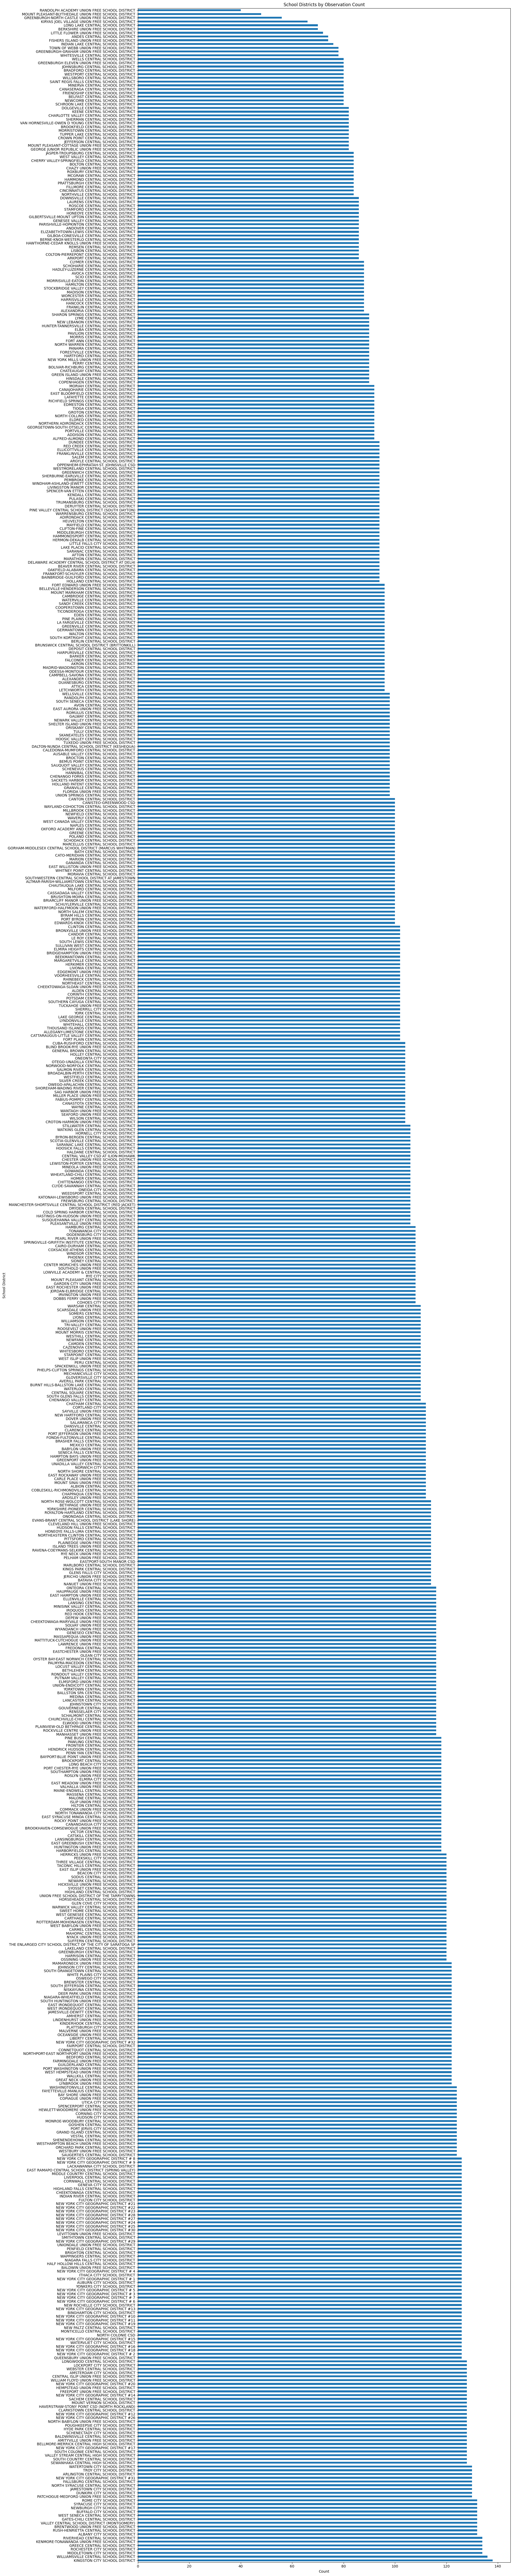

In [ ]:
# creating barchart to further analyse
import matplotlib.pyplot as plt

# Create bar chart
plt.figure(figsize=(20, 100))
district_counts.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('School District')
plt.title('School Districts by Observation Count')
plt.tight_layout()
plt.show()

The bar chart further satisfies the claim of evenly spread observations for districts.

In [ ]:
# checking to see the significance of this column with the response variable
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('dropout_cnt ~ C(aggregation_name)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                           sum_sq       df          F  PR(>F)
C(aggregation_name)  5.387348e+07    679.0  67.171665     0.0
Residual             4.606280e+07  38997.0        NaN     NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 679, but rank is 676
  warnings.warn('covariance of constraints does not have full '


###**nrc_code**

In [ ]:
#nrc_code
df['nrc_code'].describe()


,nrc_code
count,73152.000000
mean,4.588583
std,1.203507
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,6.000000


In [ ]:
print(df['nrc_code'].isnull().sum())
mapping = df['nrc_code'].unique()
print(mapping)

0
[3 5 6 4 2 1]


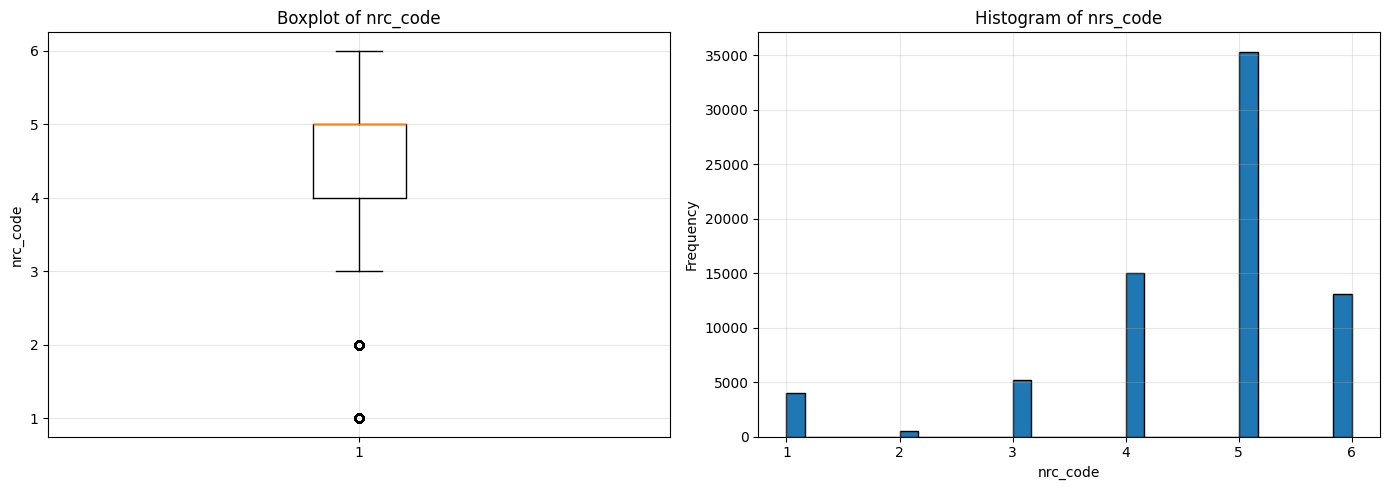

In [ ]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['nrc_code'])
axes[0].set_ylabel('nrc_code')
axes[0].set_title('Boxplot of nrc_code')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(df['nrc_code'], bins=30, edgecolor='black')
axes[1].set_xlabel('nrc_code')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of nrs_code')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The nrc code has values from 1 to 6 and is left skewed as per the histogram.

###**nrc_desc**

In [ ]:
#nrc_desc
df['nrc_desc'].describe()


,nrc_desc
count,73152
unique,6
top,Average Needs
freq,35322


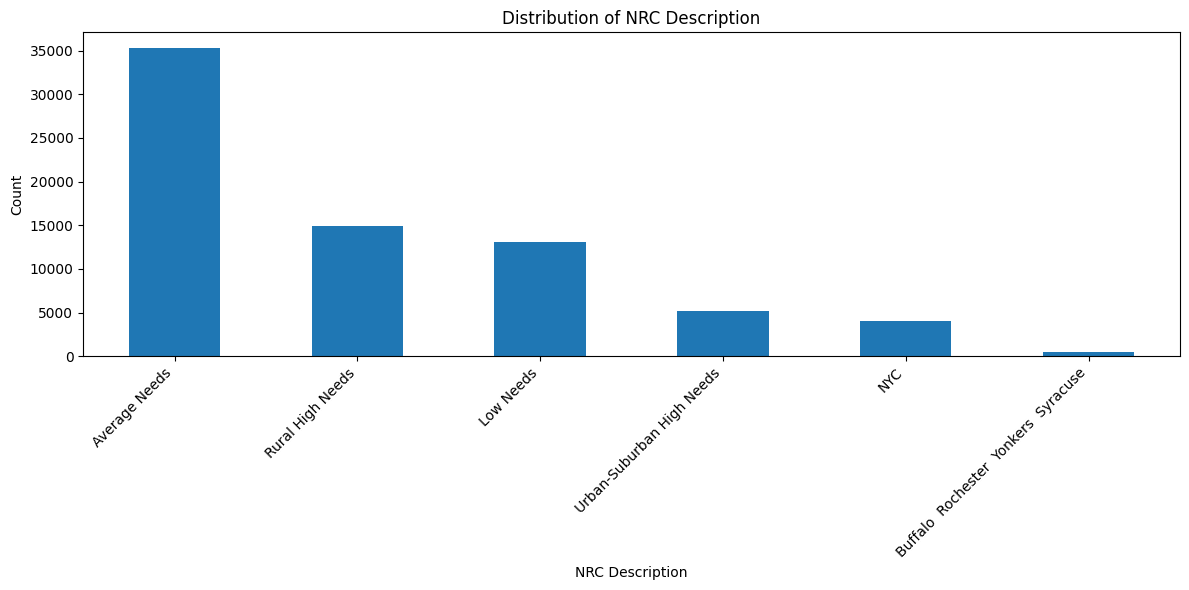

In [ ]:
 # Create bar chart for nrc_desc
nrc_desc_counts = df['nrc_desc'].value_counts()
plt.figure(figsize=(12, 6))
nrc_desc_counts.plot(kind='bar')
plt.xlabel('NRC Description')
plt.ylabel('Count')
plt.title('Distribution of NRC Description')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print(df['nrc_desc'].unique())

['Urban-Suburban High Needs' 'Average Needs' 'Low Needs'
 'Rural High Needs' 'Buffalo  Rochester  Yonkers  Syracuse' 'NYC']


There are 6 different types of nrc_desc. The values of each types seem sufficient for statistical significance so merging of these categories will not be needed.

###**county_code**

In [ ]:
#county_code
df['county_code'].describe()


,county_code
count,73152.000000
mean,36.251859
std,20.588044
min,1.000000
25%,17.000000
50%,40.000000
75%,57.000000
max,68.000000


In [ ]:
print(df['county_code'].nunique())
df['county_code'].unique()


62


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 34, 35, 40,
       41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57,
       58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68])

There are 62 unique county codes

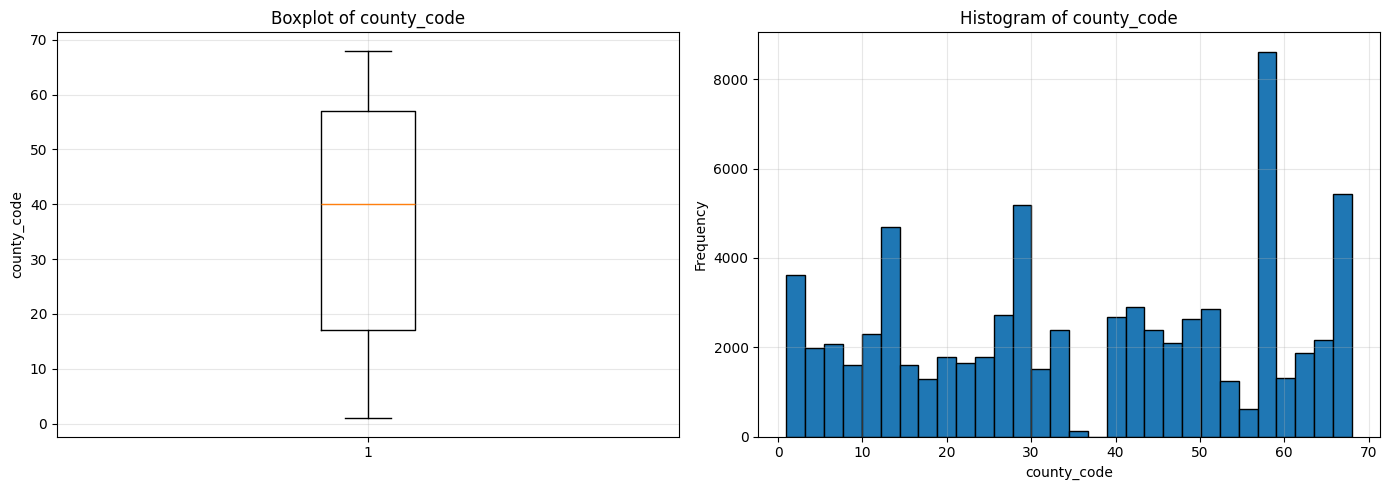

In [ ]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['county_code'])
axes[0].set_ylabel('county_code')
axes[0].set_title('Boxplot of county_code')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(df['county_code'], bins=30, edgecolor='black')
axes[1].set_xlabel('county_code')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of county_code')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **county_name**

In [ ]:
#county_name
df['county_name'].describe()

,county_name
count,73152
unique,62
top,SUFFOLK
freq,6526


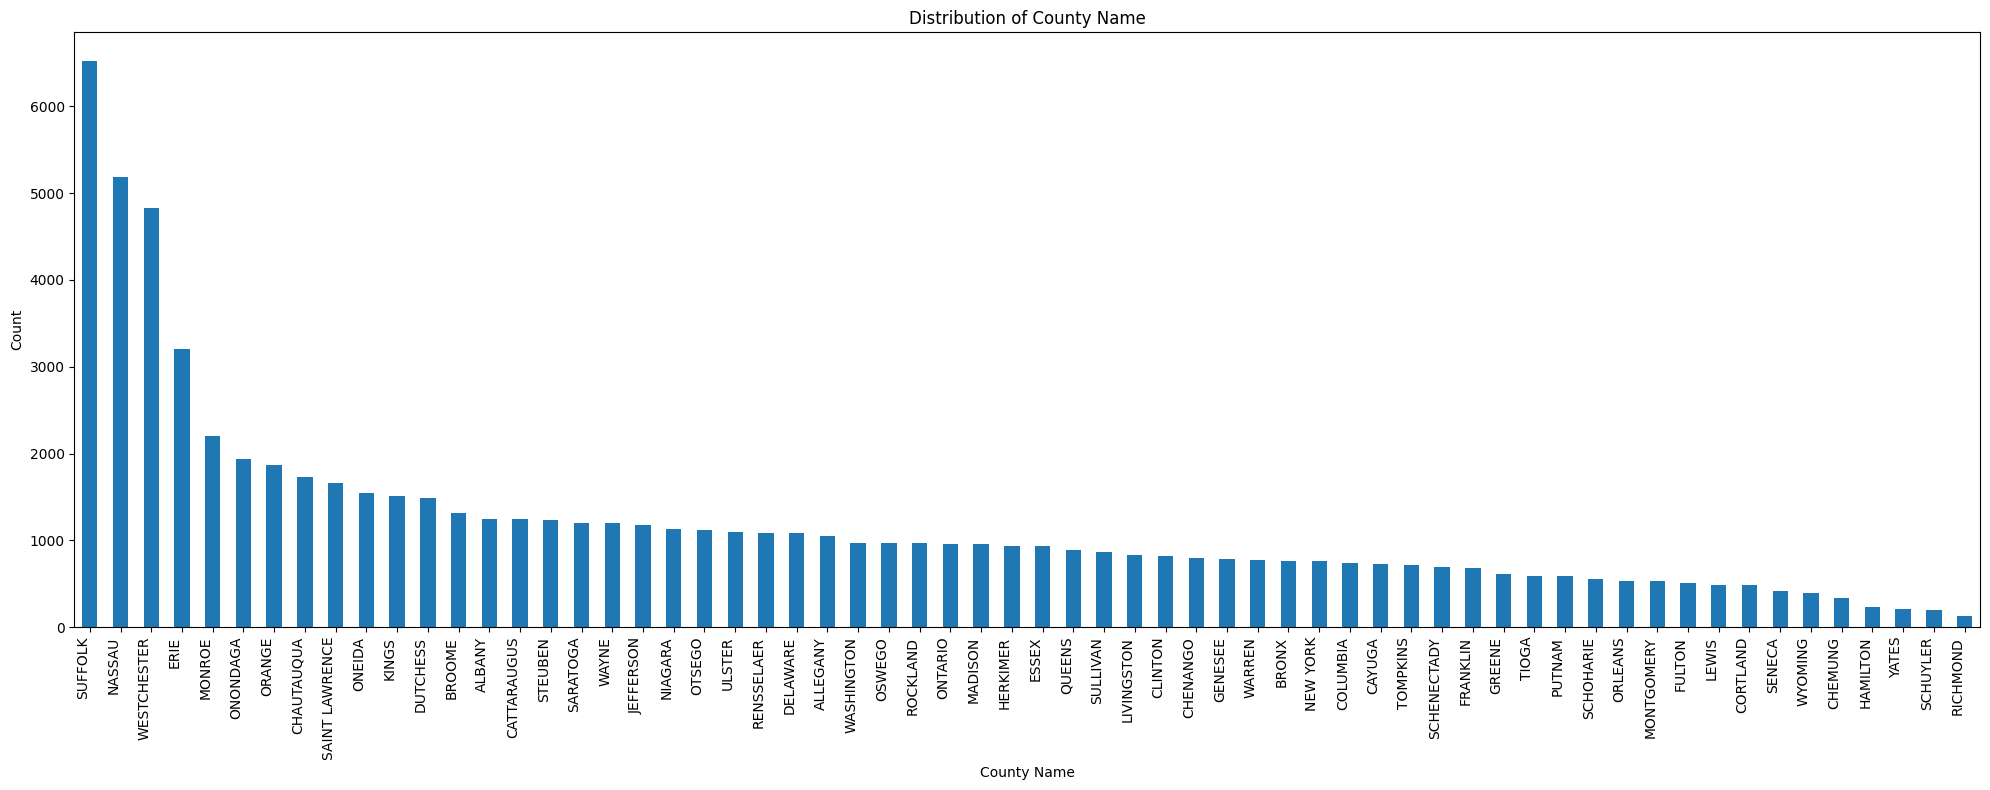

In [ ]:

  # Create bar chart for county_name
county_counts = df['county_name'].value_counts()
plt.figure(figsize=(20, 8))
county_counts.plot(kind='bar')
plt.xlabel('County Name')
plt.ylabel('Count')
plt.title('Distribution of County Name')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

###**dropout_pct**

In [ ]:

df["dropout_pct"].describe()

,dropout_pct
count,39674.000000
mean,7.963049
std,9.658698
min,0.000000
25%,1.000000
50%,5.000000
75%,11.000000
max,100.000000


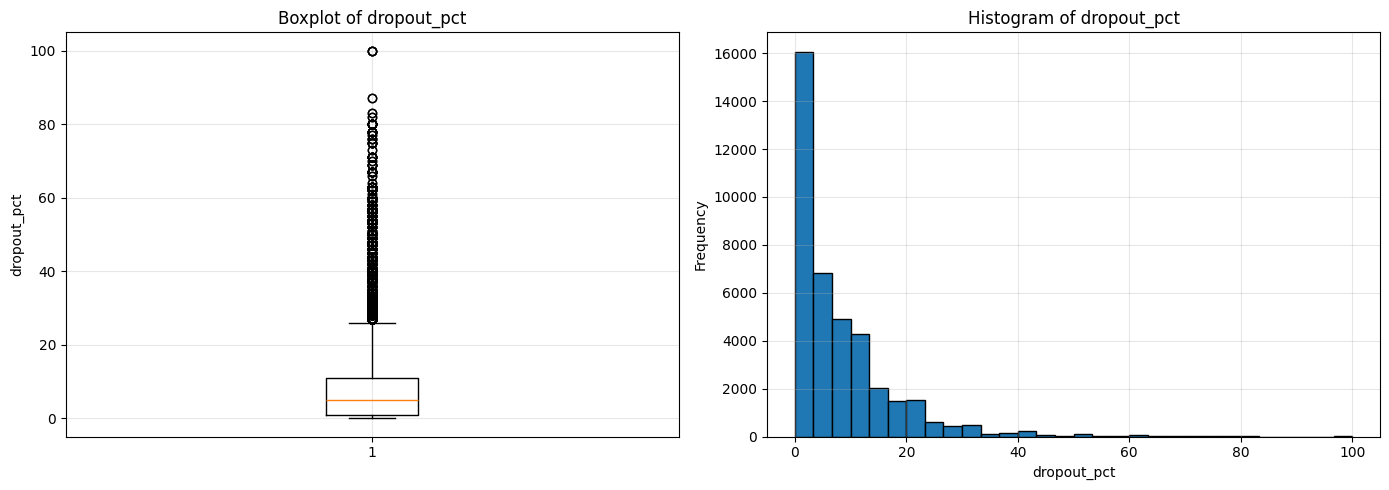

In [ ]:


# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df["dropout_pct"].dropna())
axes[0].set_ylabel('dropout_pct')
axes[0].set_title('Boxplot of dropout_pct')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(df["dropout_pct"].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('dropout_pct')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of dropout_pct')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


###**dropout_cnt**

In [ ]:
# Convert dropout_cnt to numeric (replace '-' with NaN)

df['dropout_cnt'].describe()

,dropout_cnt
count,39674.000000
mean,16.239225
std,50.129834
min,0.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,1091.000000


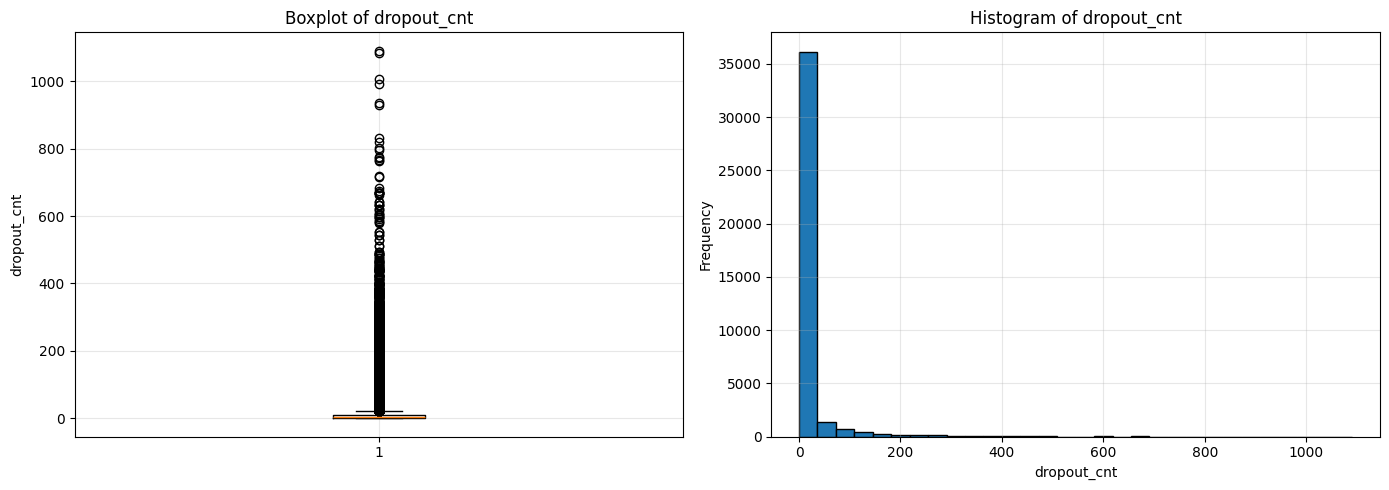

In [ ]:


# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['dropout_cnt'].dropna())
axes[0].set_ylabel('dropout_cnt')
axes[0].set_title('Boxplot of dropout_cnt')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(df['dropout_cnt'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('dropout_cnt')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of dropout_cnt')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **ged_pct**

In [ ]:
#ged_pct
df['ged_pct'].describe()

,ged_pct
count,39674.000000
mean,0.612693
std,1.985445
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,67.000000


###**ged_cnt**

In [ ]:
#ged_cnt
df['ged_cnt'].describe()

,ged_cnt
count,39674.000000
mean,1.377577
std,4.949389
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,97.000000


### **still_enr_pct**

In [ ]:
#still_enr_pct
df['still_enr_pct'].describe()

,still_enr_pct
count,39674.000000
mean,5.190704
std,8.832710
min,0.000000
25%,0.000000
50%,2.000000
75%,6.000000
max,100.000000


### **still_enr_cnt**

In [ ]:
#still_enr_cnt
df['still_enr_cnt'].describe()

,still_enr_cnt
count,39674.000000
mean,11.299516
std,40.766672
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,1381.000000


### **non_diploma_credential_pct**

In [ ]:
#non_diploma_credential_pct
df['non_diploma_credential_pct'].describe()

,non_diploma_credential_pct
count,39674.000000
mean,1.742627
std,4.063987
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,67.000000


### **non_diploma_credential_cnt**

In [ ]:
#non_diploma_credential_cnt
df['non_diploma_credential_cnt'].describe()

,non_diploma_credential_cnt
count,39674.000000
mean,1.924485
std,6.498913
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,279.000000


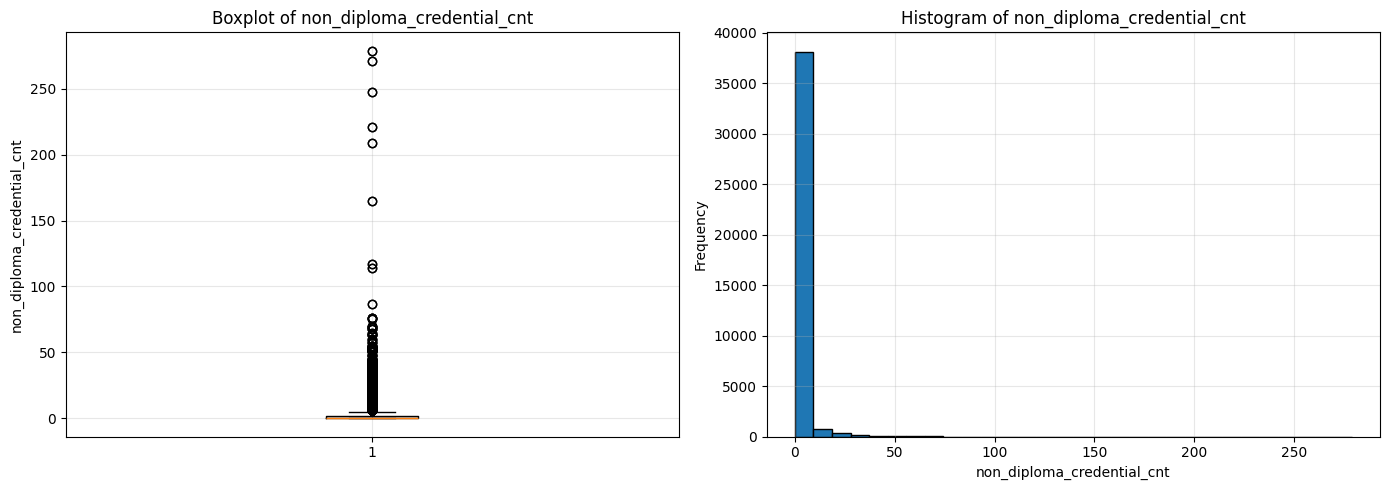

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['non_diploma_credential_cnt'].dropna())
axes[0].set_ylabel('non_diploma_credential_cnt')
axes[0].set_title('Boxplot of non_diploma_credential_cnt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['non_diploma_credential_cnt'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('non_diploma_credential_cnt')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of non_diploma_credential_cnt')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **reg_avg_pct**

In [ ]:
#reg_adv_pct
df['reg_adv_pct'].describe()

,reg_adv_pct
count,39674.000000
mean,32.577204
std,23.001197
min,0.000000
25%,14.000000
50%,31.000000
75%,49.000000
max,100.000000


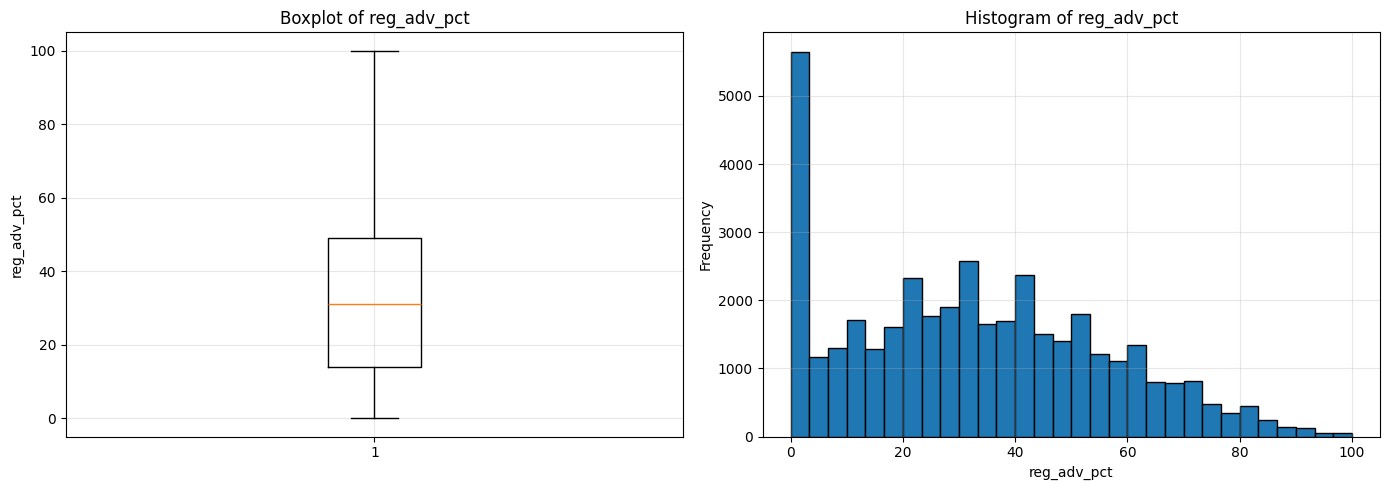

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['reg_adv_pct'].dropna())
axes[0].set_ylabel('reg_adv_pct')
axes[0].set_title('Boxplot of reg_adv_pct')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['reg_adv_pct'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('reg_adv_pct')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of reg_adv_pct')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **reg_avg_cnt**

In [ ]:
#reg_adv_cnt
df['reg_adv_cnt'].describe()

,reg_adv_cnt
count,39674.000000
mean,62.032742
std,132.777866
min,0.000000
25%,4.000000
50%,18.000000
75%,62.000000
max,2231.000000


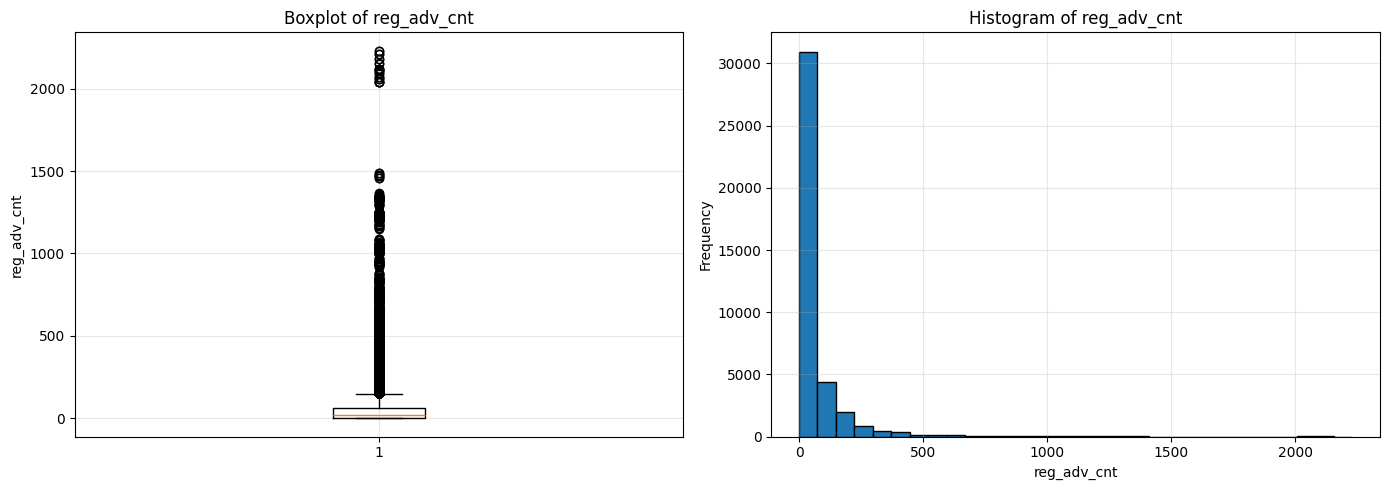

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['reg_adv_cnt'].dropna())
axes[0].set_ylabel('reg_adv_cnt')
axes[0].set_title('Boxplot of reg_adv_cnt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['reg_adv_cnt'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('reg_adv_cnt')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of reg_adv_cnt')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **reg_pct**

In [ ]:
#reg_pct
df['reg_pct'].describe()

,reg_pct
count,39674.000000
mean,43.371125
std,17.124891
min,0.000000
25%,33.000000
50%,43.000000
75%,53.000000
max,100.000000


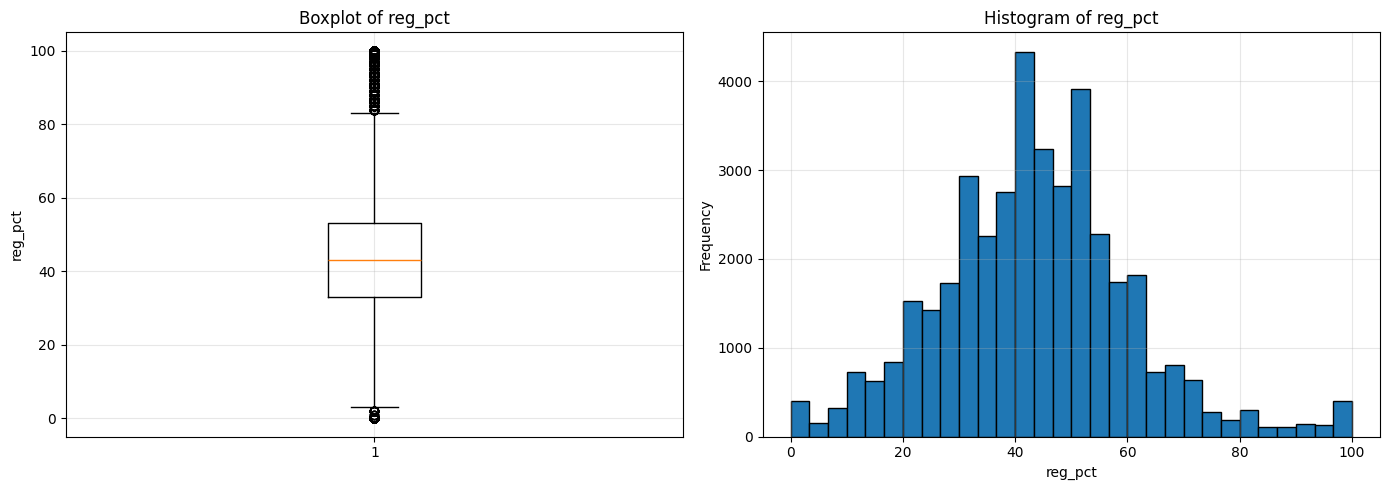

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['reg_pct'].dropna())
axes[0].set_ylabel('reg_pct')
axes[0].set_title('Boxplot of reg_pct')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['reg_pct'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('reg_pct')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of reg_pct')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **reg_cnt**

In [ ]:
#reg_cnt
df['reg_cnt'].describe()

,reg_cnt
count,39674.000000
mean,86.804708
std,225.795826
min,0.000000
25%,10.000000
50%,27.000000
75%,69.000000
max,4752.000000


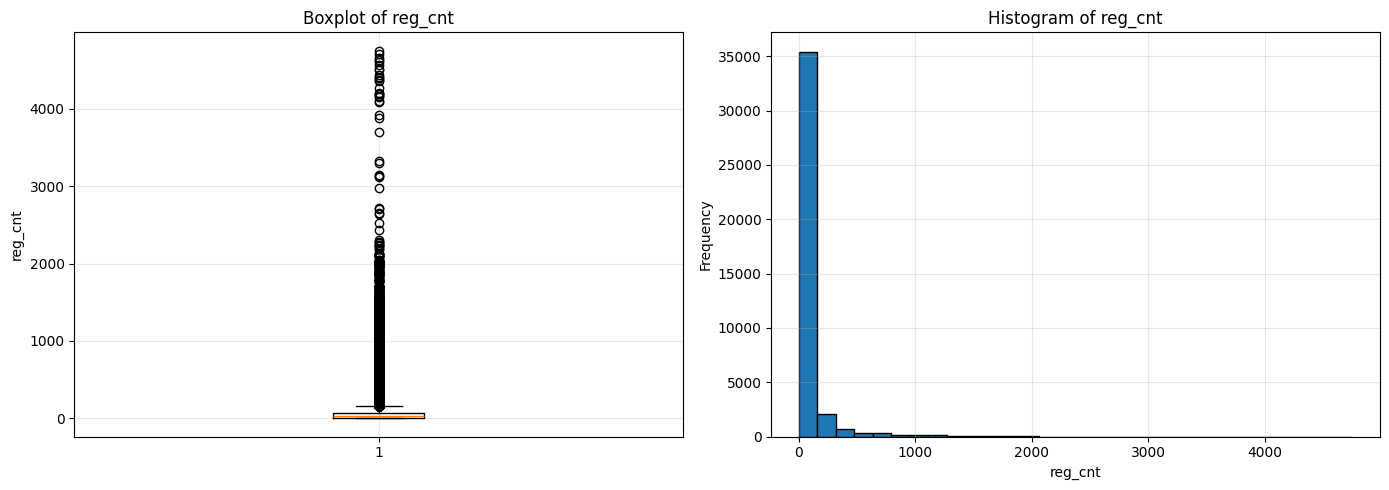

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['reg_cnt'].dropna())
axes[0].set_ylabel('reg_cnt')
axes[0].set_title('Boxplot of reg_cnt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['reg_cnt'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('reg_cnt')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of reg_cnt')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **local_pct**

In [ ]:
#local_pct
df['local_pct'].describe()

,local_pct
count,39674.000000
mean,8.479936
std,10.398486
min,0.000000
25%,2.000000
50%,6.000000
75%,11.000000
max,100.000000


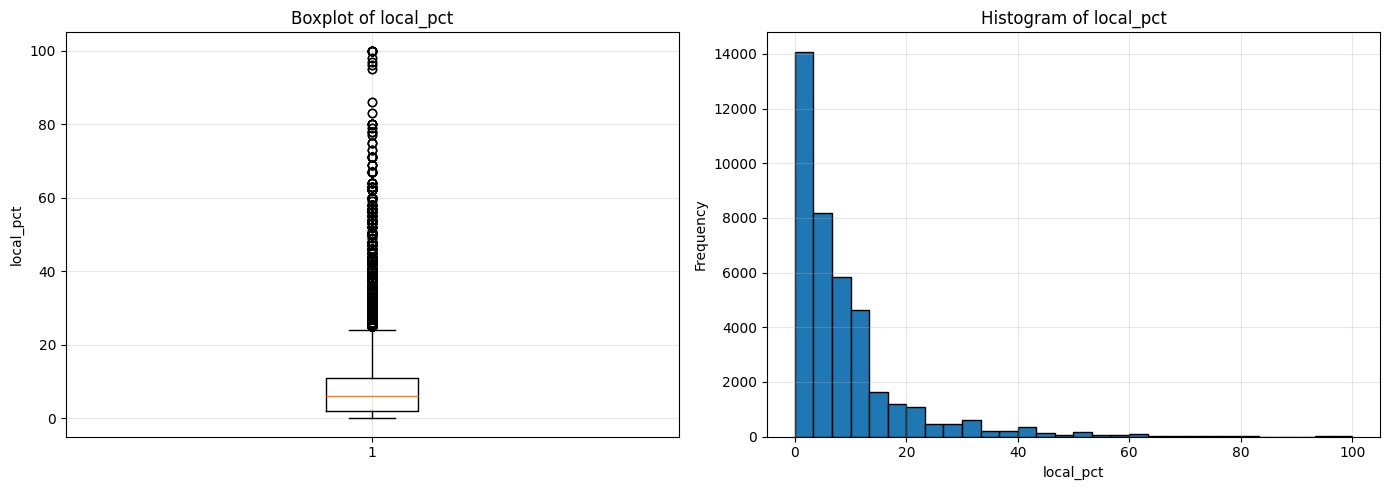

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['local_pct'].dropna())
axes[0].set_ylabel('local_pct')
axes[0].set_title('Boxplot of local_pct')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['local_pct'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('local_pct')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of local_pct')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **local_cnt**

In [ ]:
#local_cnt
df['local_cnt'].describe()

,local_cnt
count,39674.000000
mean,12.340903
std,32.046302
min,0.000000
25%,1.000000
50%,4.000000
75%,10.000000
max,557.000000


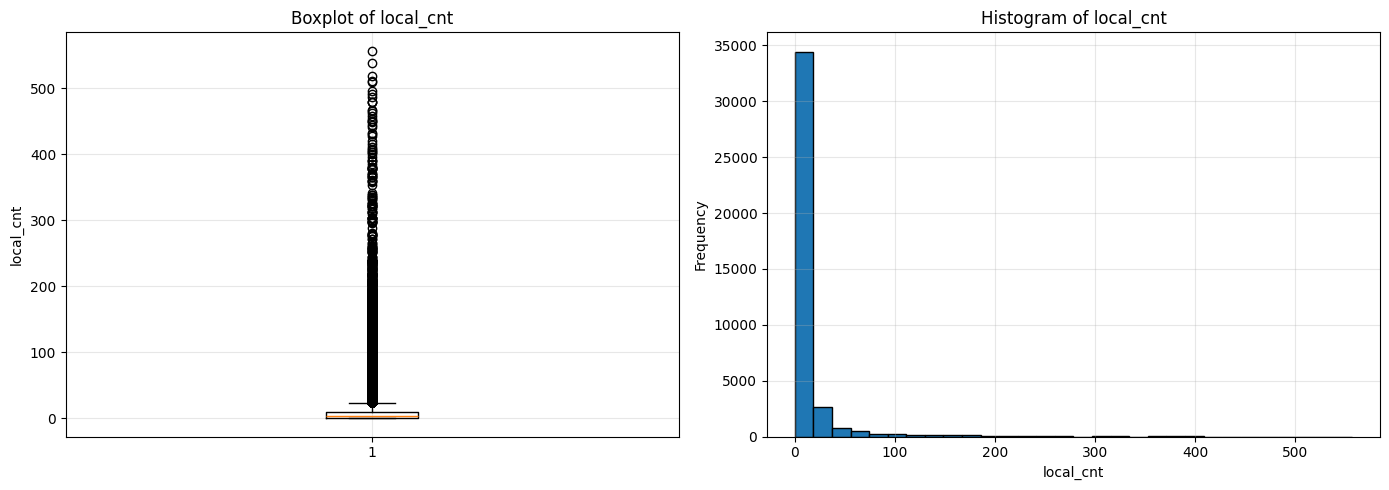

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['local_cnt'].dropna())
axes[0].set_ylabel('local_cnt')
axes[0].set_title('Boxplot of local_cnt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['local_cnt'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('local_cnt')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of local_cnt')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **grad_pct**

In [ ]:
#grad_pct
df['grad_pct'].describe()

,grad_pct
count,39674.000000
mean,84.406614
std,15.679500
min,0.000000
25%,79.000000
50%,89.000000
75%,95.000000
max,100.000000


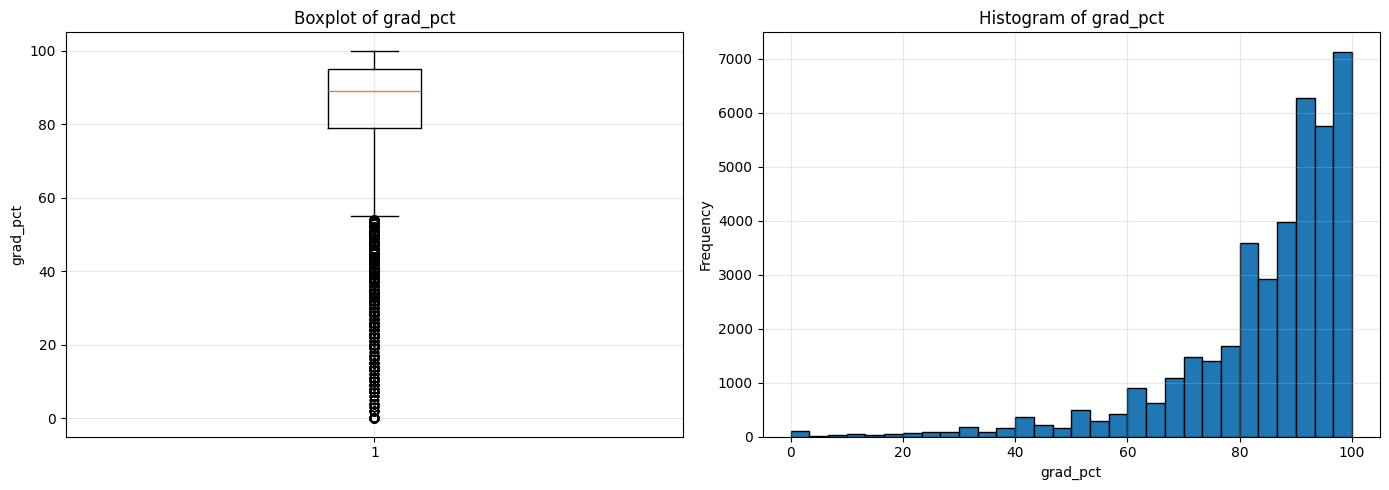

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['grad_pct'].dropna())
axes[0].set_ylabel('grad_pct')
axes[0].set_title('Boxplot of grad_pct')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['grad_pct'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('grad_pct')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of grad_pct')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **grad_cnt**

In [ ]:
#grad_cnt
df['grad_cnt'].describe()

,grad_cnt
count,39674.000000
mean,161.178354
std,361.294773
min,0.000000
25%,20.000000
50%,57.000000
75%,156.000000
max,7540.000000


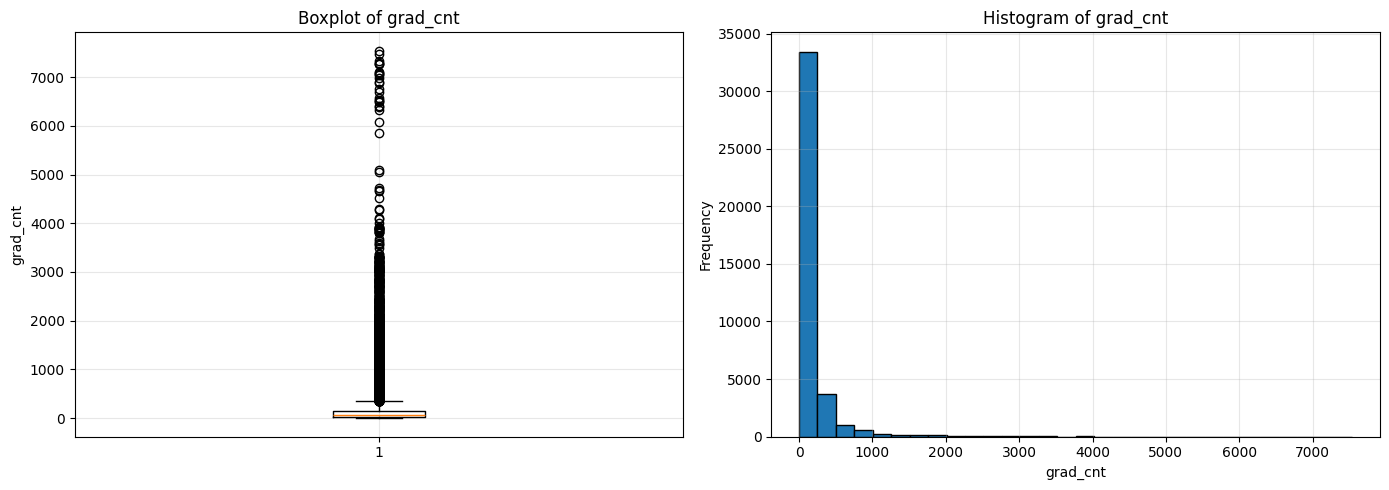

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['grad_cnt'].dropna())
axes[0].set_ylabel('grad_cnt')
axes[0].set_title('Boxplot of grad_cnt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['grad_cnt'].dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('grad_cnt')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of grad_cnt')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **enroll_cnt**

In [ ]:
#enroll_cnt
df['enroll_cnt'].describe()

,enroll_cnt
count,39674.000000
mean,192.120079
std,439.972474
min,5.000000
25%,25.000000
50%,66.000000
75%,179.000000
max,9176.000000


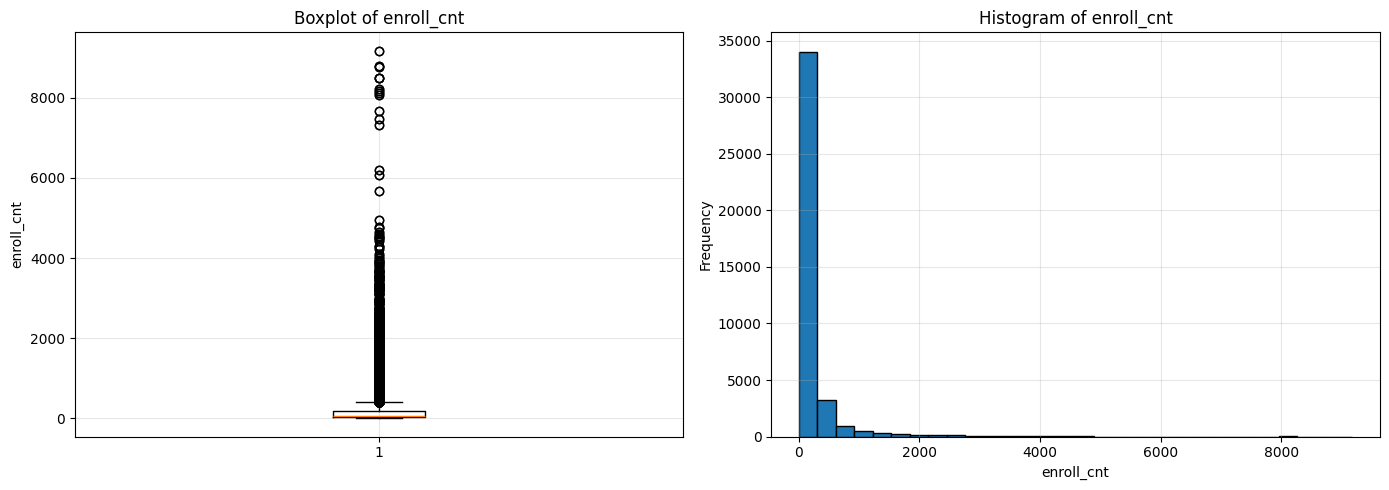

In [ ]:
# enroll_cnt
enroll_cnt_numeric = pd.to_numeric(df['enroll_cnt'].replace('-', None), errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(enroll_cnt_numeric.dropna())
axes[0].set_ylabel('enroll_cnt')
axes[0].set_title('Boxplot of enroll_cnt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(enroll_cnt_numeric.dropna(), bins=30, edgecolor='black')
axes[1].set_xlabel('enroll_cnt')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of enroll_cnt')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **subgroup_name**

In [ ]:
#subgroup_name
df['subgroup_name'].describe()

,subgroup_name
count,73152
unique,24
top,All Students
freq,4074


In [ ]:
subgroup_count = df['subgroup_name'].value_counts()
subgroup_count

,count
subgroup_name,
All Students,4074
Not Migrant,4074
Parent Not in Armed Forces,4074
Not Homeless,4074
Not in Foster Care,4070
Male,4068
Not English Language Learner,4068
Female,4060
General Education Students,4056


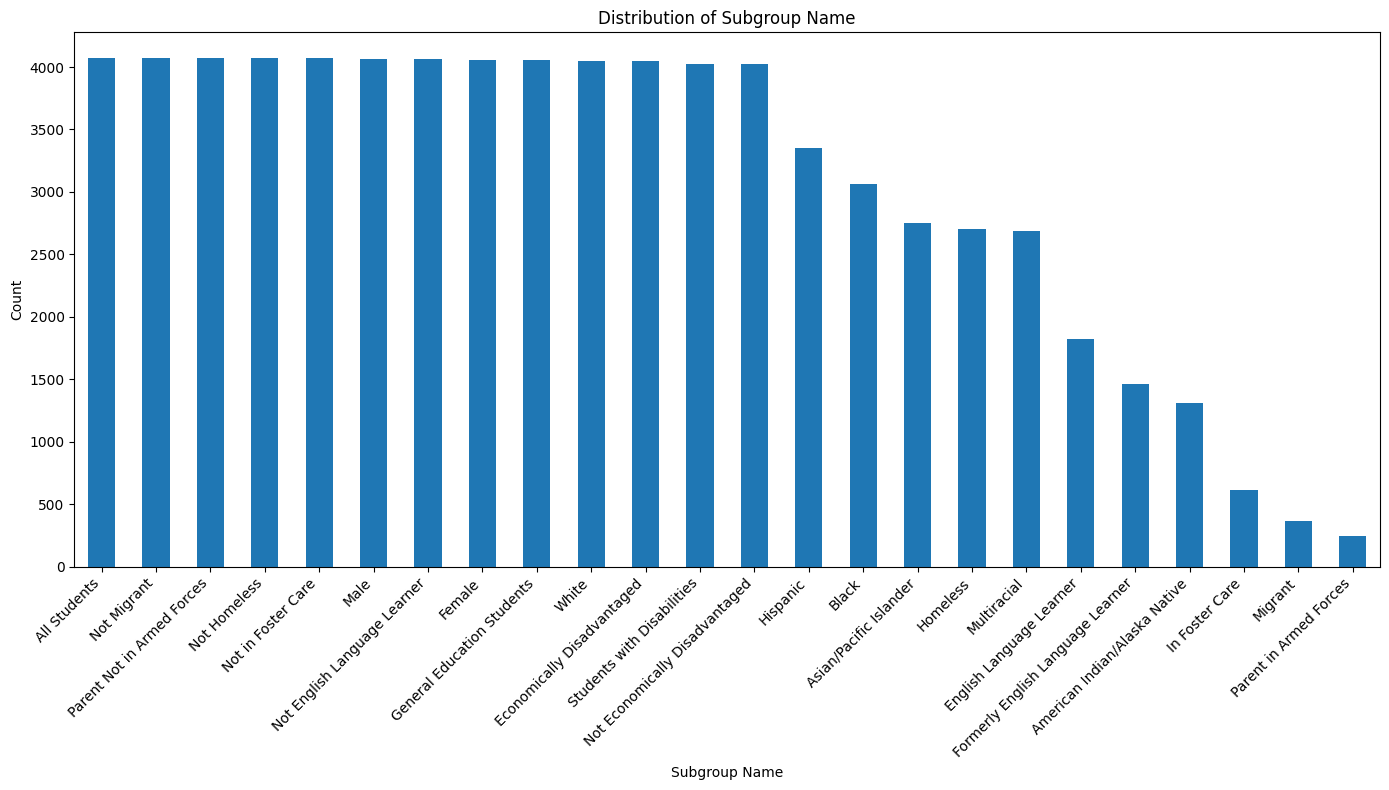

In [ ]:
 # Create bar chart for subgroup_name

plt.figure(figsize=(14, 8))
subgroup_count.plot(kind='bar')
plt.xlabel('Subgroup Name')
plt.ylabel('Count')
plt.title('Distribution of Subgroup Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **subgroup_code**

In [ ]:
#subgroup_code
df['subgroup_code'].describe()

,subgroup_code
count,73152.000000
mean,12.000930
std,7.213138
min,1.000000
25%,6.000000
50%,11.000000
75%,18.000000
max,25.000000


### **membership_desc**

In [ ]:
#membership_desc
df['membership_desc'].describe()

,membership_desc
count,73152
unique,6
top,2015 Total Cohort - 4 Year Outcome - August 2019
freq,12299


In [ ]:
membership_count = df['membership_desc'].value_counts()
membership_count

,count
membership_desc,
2015 Total Cohort - 4 Year Outcome - August 2019,12299
2015 Total Cohort - 4 Year Outcome,12299
2014 Total Cohort - 5 Year Outcome - August 2019,12257
2014 Total Cohort - 5 Year Outcome,12257
2013 Total Cohort - 6 Year Outcome,12020
2013 Total Cohort - 6 Year Outcome - August 2019,12020


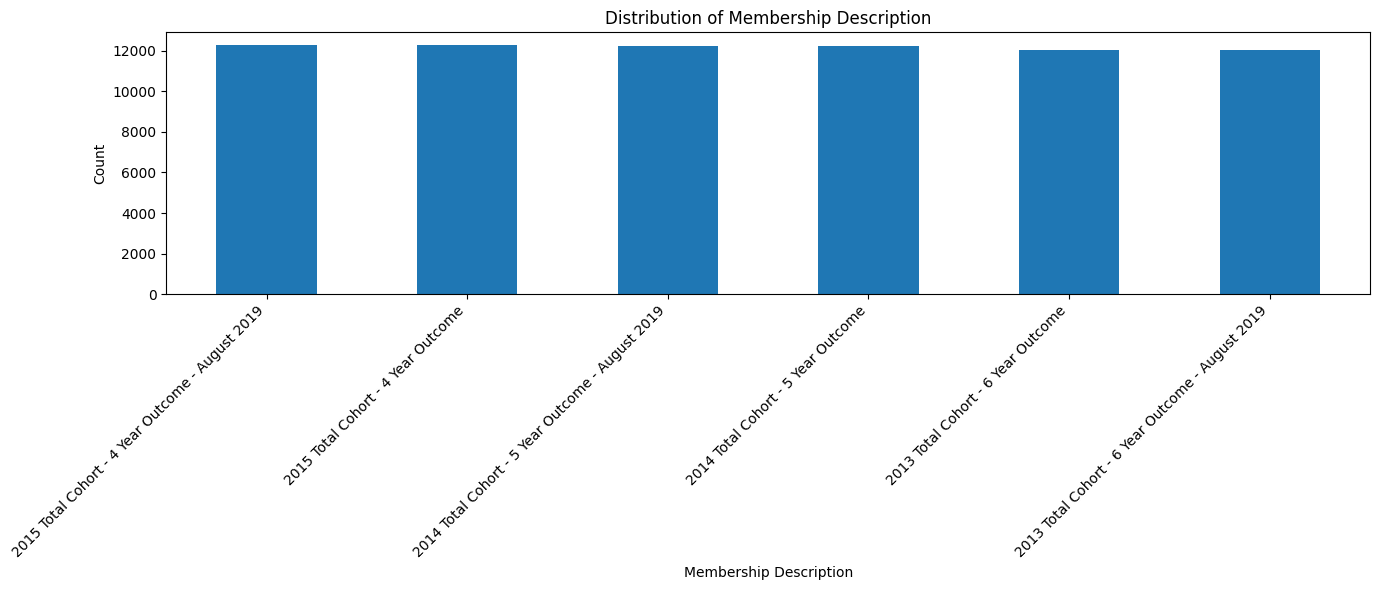

In [ ]:
# Create bar chart for membership_desc
plt.figure(figsize=(14, 6))
membership_count.plot(kind='bar')
plt.xlabel('Membership Description')
plt.ylabel('Count')
plt.title('Distribution of Membership Description')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **nyc_ind**

In [ ]:
#nyc_ind
df['nyc_ind'].describe()

,nyc_ind
count,73152.000000
mean,0.055255
std,0.228479
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


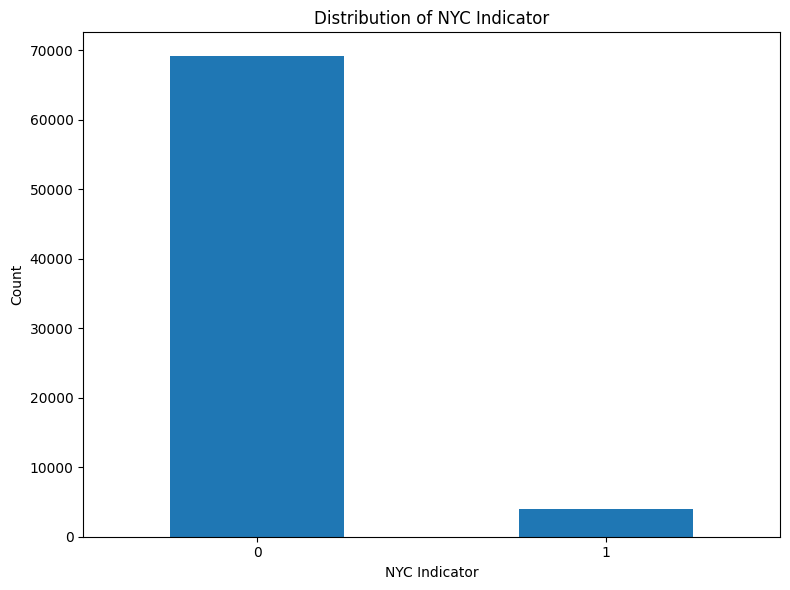

In [ ]:
# Create bar chart for nyc_ind
nyc_ind_counts = df['nyc_ind'].value_counts()
plt.figure(figsize=(8, 6))
nyc_ind_counts.plot(kind='bar')
plt.xlabel('NYC Indicator')
plt.ylabel('Count')
plt.title('Distribution of NYC Indicator')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## **Bivariate Analysis**

### **nrc_code & nrc_desc**

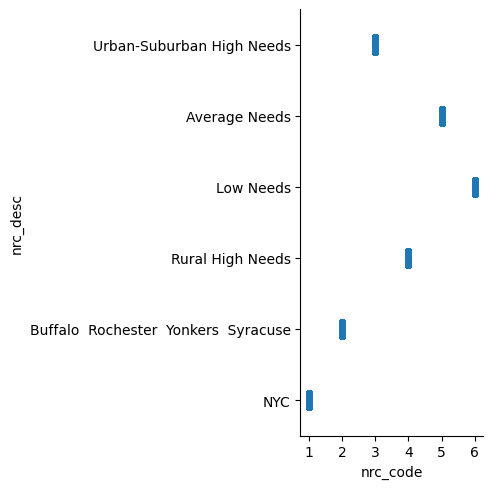

In [ ]:
import seaborn as sns
sns.catplot(data=df, x="nrc_code", y="nrc_desc", kind='strip')
plt.xticks([1, 2, 3, 4, 5, 6])  # Force ticks at each integer
plt.show()


Here, the nrc_code and nrc_desc represent the same thing and categorical column is nominal. We will keep the nrc_desc column and drop the nrc_code and then perform one_hot encoding for use on the model.

### **county_code & county_name**

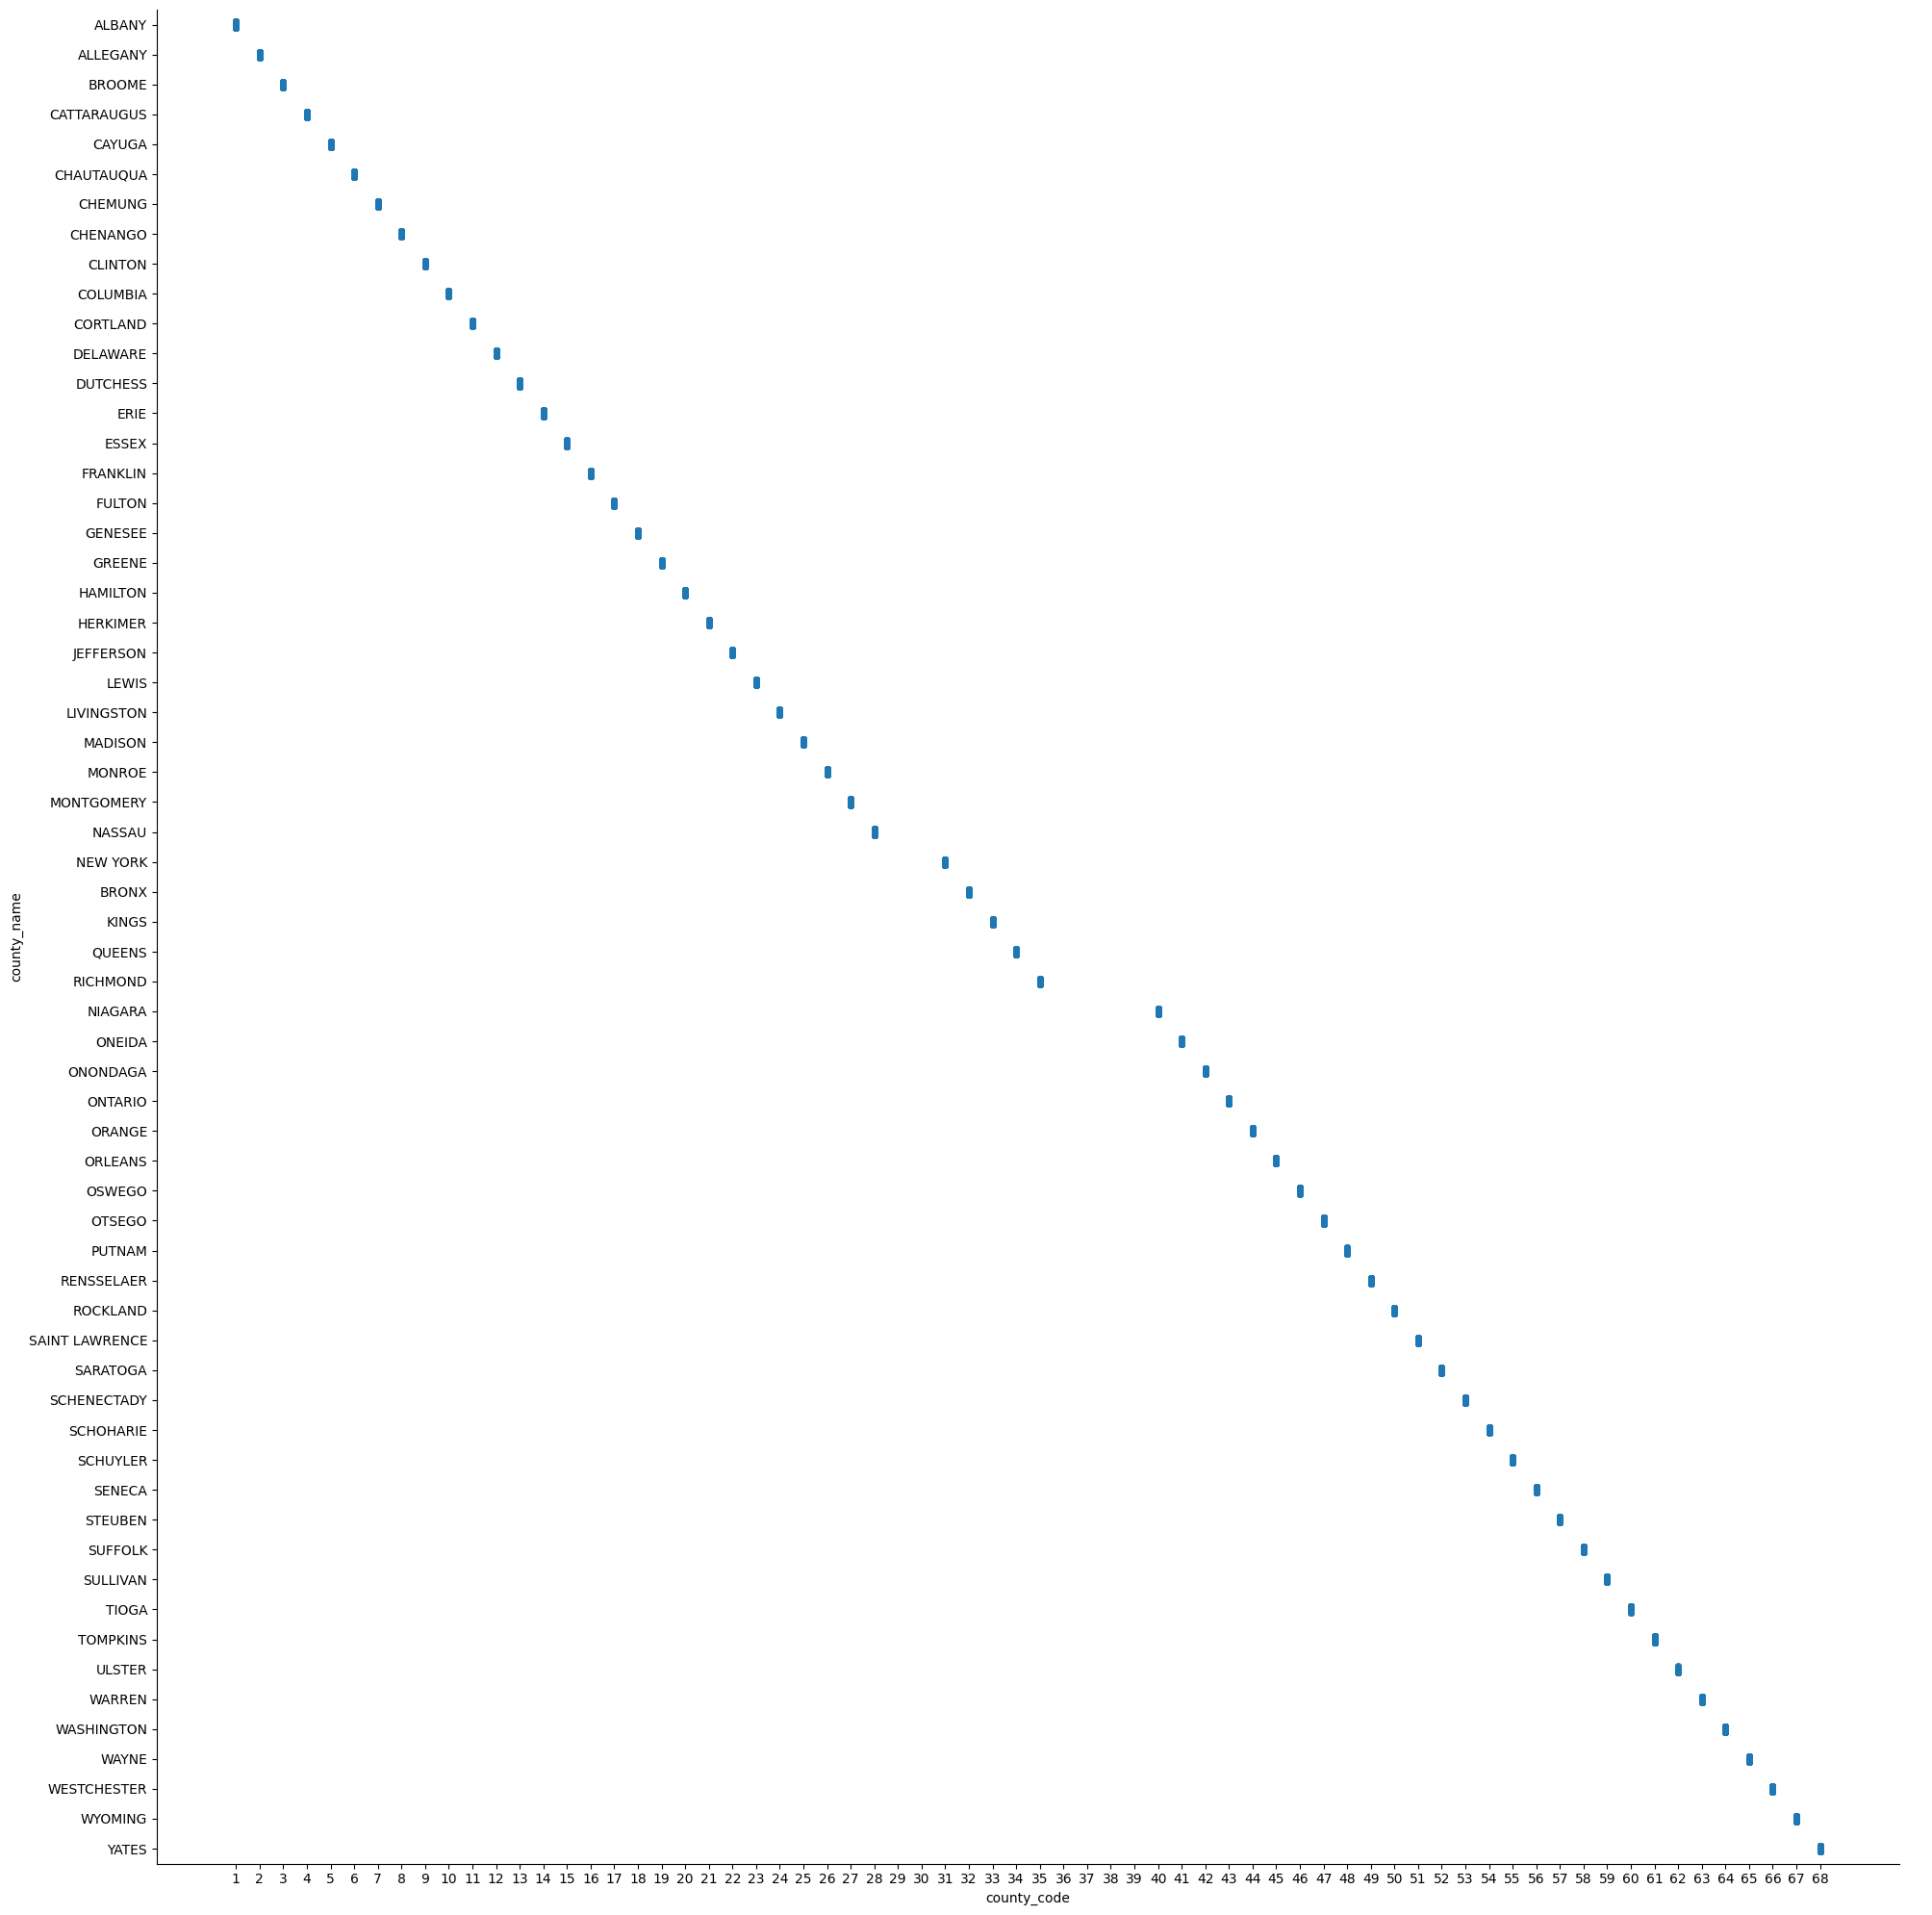

In [ ]:
import numpy as np
g = sns.catplot(data=df, x="county_code", y="county_name", kind='strip', height=20)
g.ax.set_xticks(np.arange(df['county_code'].min(), df['county_code'].max() + 1, 1))
plt.show()

It is verified that the coudes are mapped with the names

### **reg_cnt & reg_adv_cnt**

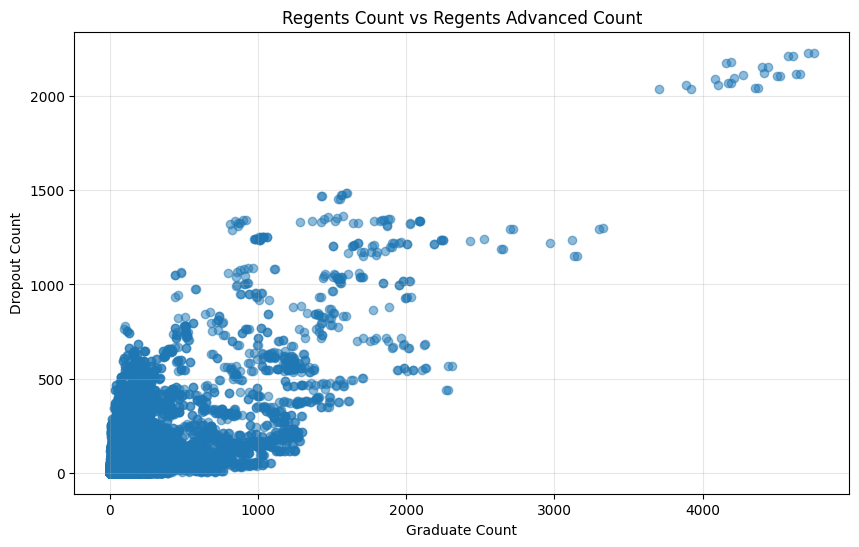

Correlation Matrix:
              reg_cnt  reg_adv_cnt
reg_cnt      1.000000     0.744442
reg_adv_cnt  0.744442     1.000000


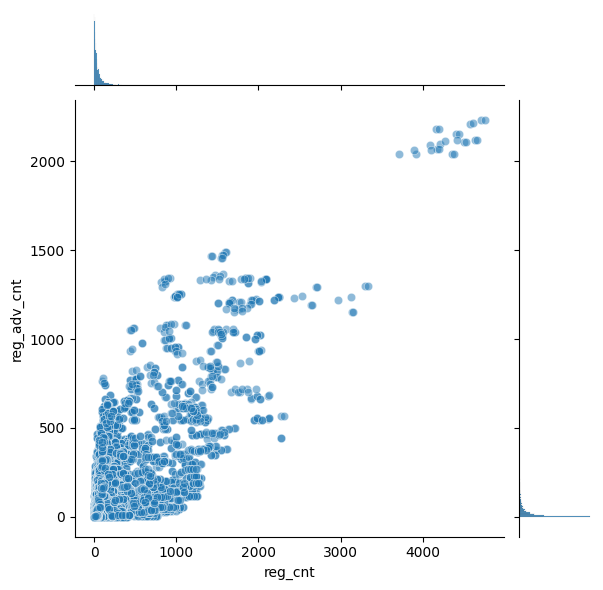


Summary Statistics:
            reg_cnt   reg_adv_cnt
count  39674.000000  39674.000000
mean      86.804708     62.032742
std      225.795826    132.777866
min        0.000000      0.000000
25%       10.000000      4.000000
50%       27.000000     18.000000
75%       69.000000     62.000000
max     4752.000000   2231.000000


In [ ]:
# Scatter plot to see relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['reg_cnt'], df['reg_adv_cnt'], alpha=0.5)
plt.xlabel('Graduate Count')
plt.ylabel('Dropout Count')
plt.title('Regents Count vs Regents Advanced Count')
plt.grid(True, alpha=0.3)
plt.show()

# Correlation
correlation = df[['reg_cnt', 'reg_adv_cnt']].corr()
print("Correlation Matrix:")
print(correlation)

# Joint plot with distributions
sns.jointplot(data=df, x='reg_cnt', y='reg_adv_cnt', kind='scatter', alpha=0.5)
plt.show()

# Summary statistics
print("\nSummary Statistics:")
print(df[['reg_cnt', 'reg_adv_cnt']].describe())

There's high correlation between the regents diploma and regents advance diploma holders.

## **Multivariate Analysis**

### **enroll_cnt & grad_cnt & still_enr_cnt & dropout_cnt**

Overall Correlation Matrix:
               enroll_cnt  grad_cnt  still_enr_cnt  dropout_cnt
enroll_cnt       1.000000  0.993603       0.762840     0.846691
grad_cnt         0.993603  1.000000       0.708722     0.795895
still_enr_cnt    0.762840  0.708722       1.000000     0.662578
dropout_cnt      0.846691  0.795895       0.662578     1.000000


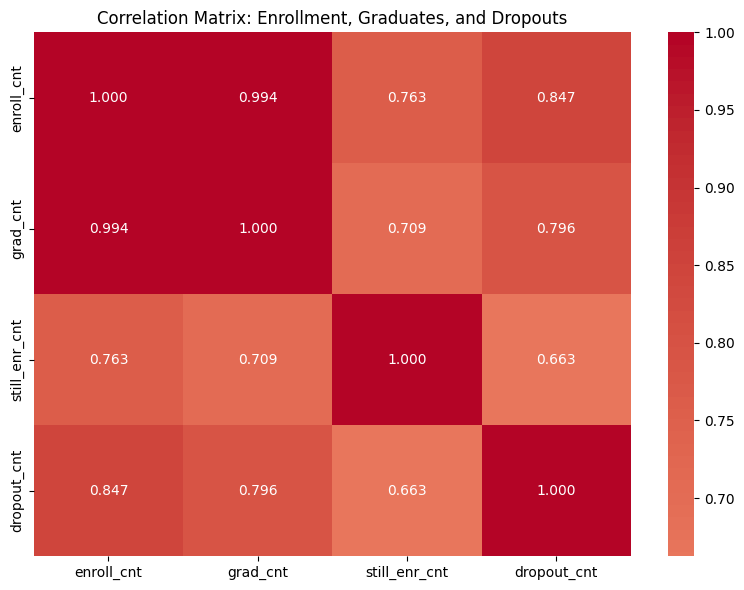

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Filter out nulls
df_multivariate = df[['subgroup_name', 'enroll_cnt', 'grad_cnt', 'dropout_cnt','still_enr_cnt']].dropna()

# 1. Overall correlation (all data combined)
correlation = df_multivariate[['enroll_cnt', 'grad_cnt','still_enr_cnt', 'dropout_cnt']].corr()
print("Overall Correlation Matrix:")
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix: Enrollment, Graduates, and Dropouts')
plt.tight_layout()
plt.show()

There is high correlation between the number of students enrolled, number of students graduated, number of students still enrolled and number of students dropped out.

### **local_cnt & reg_cnt & reg_adv_cnt & non_diploma_credential_cnt & dropout_cnt**

Overall Correlation Matrix:
                            local_cnt   reg_cnt  reg_adv_cnt  \
local_cnt                    1.000000  0.817128     0.520575   
reg_cnt                      0.817128  1.000000     0.744442   
reg_adv_cnt                  0.520575  0.744442     1.000000   
non_diploma_credential_cnt   0.587427  0.515351     0.284526   
dropout_cnt                  0.871071  0.851021     0.508226   

                            non_diploma_credential_cnt  dropout_cnt  
local_cnt                                     0.587427     0.871071  
reg_cnt                                       0.515351     0.851021  
reg_adv_cnt                                   0.284526     0.508226  
non_diploma_credential_cnt                    1.000000     0.584549  
dropout_cnt                                   0.584549     1.000000  


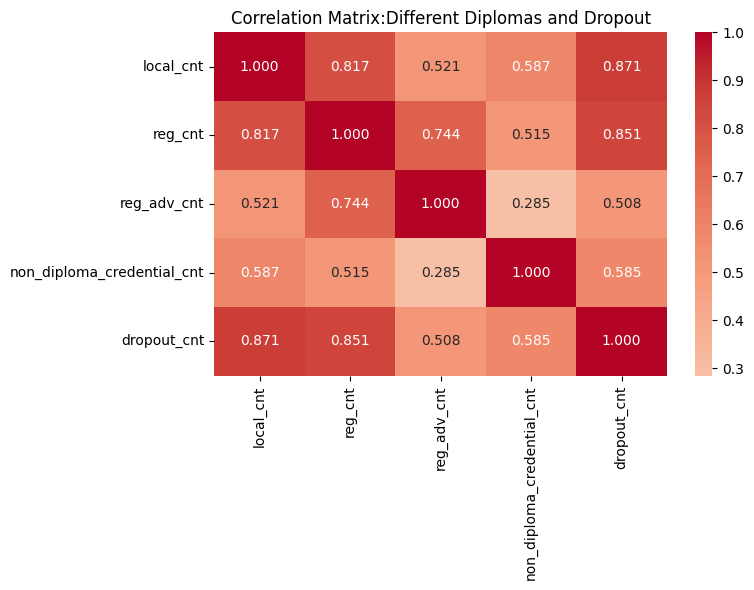

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Filter out nulls
df_multivariate = df[['subgroup_name', 'local_cnt', 'reg_cnt', 'reg_adv_cnt','non_diploma_credential_cnt','dropout_cnt']].dropna()

# 1. Overall correlation (all data combined)
correlation = df_multivariate[['local_cnt', 'reg_cnt', 'reg_adv_cnt','non_diploma_credential_cnt','dropout_cnt']].corr()
print("Overall Correlation Matrix:")
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix:Different Diplomas and Dropout')
plt.tight_layout()
plt.show()

Overall Correlation Matrix:
                            local_cnt   reg_cnt  reg_adv_cnt  \
local_cnt                    1.000000  0.817128     0.520575   
reg_cnt                      0.817128  1.000000     0.744442   
reg_adv_cnt                  0.520575  0.744442     1.000000   
non_diploma_credential_cnt   0.587427  0.515351     0.284526   
dropout_cnt                  0.871071  0.851021     0.508226   

                            non_diploma_credential_cnt  dropout_cnt  
local_cnt                                     0.587427     0.871071  
reg_cnt                                       0.515351     0.851021  
reg_adv_cnt                                   0.284526     0.508226  
non_diploma_credential_cnt                    1.000000     0.584549  
dropout_cnt                                   0.584549     1.000000  


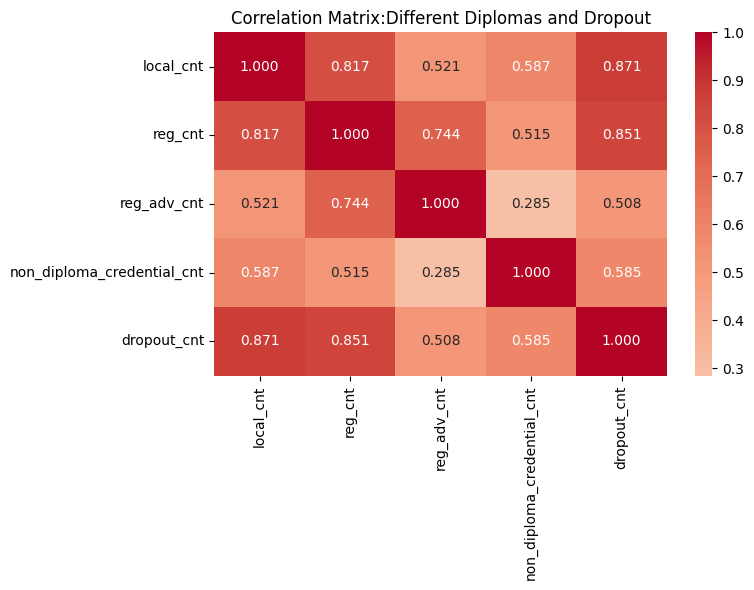

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Filter out nulls
df_multivariate = df[['subgroup_name', 'local_cnt', 'reg_cnt', 'reg_adv_cnt','non_diploma_credential_cnt','dropout_cnt']].dropna()

# 1. Overall correlation (all data combined)
correlation = df_multivariate[['local_cnt', 'reg_cnt', 'reg_adv_cnt','non_diploma_credential_cnt','dropout_cnt']].corr()
print("Overall Correlation Matrix:")
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix:Different Diplomas and Dropout')
plt.tight_layout()
plt.show()

Overall Correlation Matrix:
                            local_cnt   reg_cnt  reg_adv_cnt  \
local_cnt                    1.000000  0.817128     0.520575   
reg_cnt                      0.817128  1.000000     0.744442   
reg_adv_cnt                  0.520575  0.744442     1.000000   
non_diploma_credential_cnt   0.587427  0.515351     0.284526   
dropout_cnt                  0.871071  0.851021     0.508226   

                            non_diploma_credential_cnt  dropout_cnt  
local_cnt                                     0.587427     0.871071  
reg_cnt                                       0.515351     0.851021  
reg_adv_cnt                                   0.284526     0.508226  
non_diploma_credential_cnt                    1.000000     0.584549  
dropout_cnt                                   0.584549     1.000000  


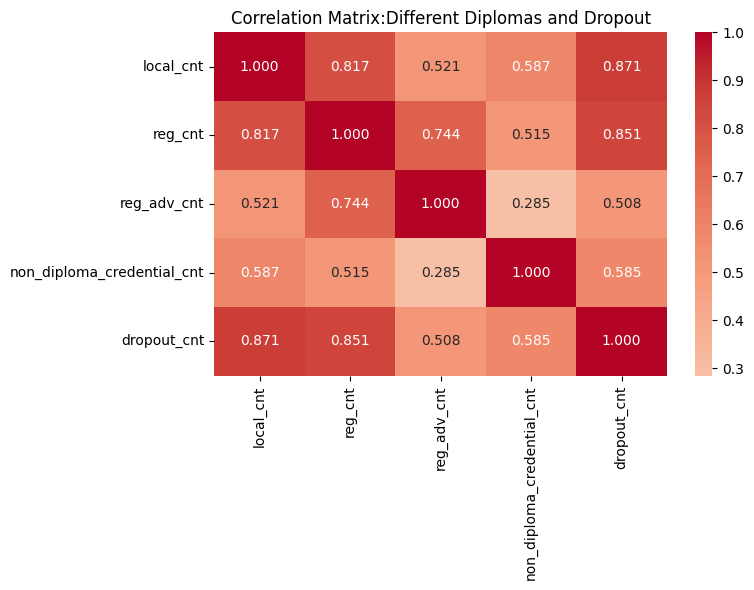

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Filter out nulls
df_multivariate = df[['subgroup_name', 'local_cnt', 'reg_cnt', 'reg_adv_cnt','non_diploma_credential_cnt','dropout_cnt']].dropna()

# 1. Overall correlation (all data combined)
correlation = df_multivariate[['local_cnt', 'reg_cnt', 'reg_adv_cnt','non_diploma_credential_cnt','dropout_cnt']].corr()
print("Overall Correlation Matrix:")
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix:Different Diplomas and Dropout')
plt.tight_layout()
plt.show()

- Strong positive correlations exist between diploma counts (local_cnt, reg_cnt, reg_adv_cnt) and dropout_cnt, because larger schools or districts tend to have higher numbers across all categories.
- local_cnt and reg_cnt show the strongest relationships with dropouts (0.87   and 0.85)
- reg_adv_cnt has a weaker correlation with dropouts (0.51), indicating that districts with more advanced diplomas may experience relatively fewer dropouts.

#**4. Data Preparation**

###**Handling Missing Values**

In [ ]:
# checking null values for different sub groups
pd.set_option('display.max_rows', None)  # Show all rows
df.groupby('subgroup_name')['enroll_cnt'].apply(lambda x: pd.Series({
    'null_count': x.isna().sum(),
    'non_null_count': x.notna().sum(),
    'total': len(x)
}))

subgroup_name                                    
All Students                       null_count          28
                                   non_null_count    4046
                                   total             4074
American Indian/Alaska Native      null_count        1042
                                   non_null_count     270
                                   total             1312
Asian/Pacific Islander             null_count        1630
                                   non_null_count    1122
                                   total             2752
Black                              null_count        1650
                                   non_null_count    1416
                                   total             3066
Economically Disadvantaged         null_count         128
                                   non_null_count    3918
                                   total             4046
English Language Learner           null_count         952
                                   non_null_count     872
                                   total             1824
Female                             null_count          90
                                   non_null_count    3970
                                   total             4060
Formerly English Language Learner  null_count         892
                                   non_null_count     572
                                   total             1464
General Education Students         null_count         424
                                   non_null_count    3632
                                   total             4056
Hispanic                           null_count        1474
                                   non_null_count    1878
                                   total             3352
Homeless                           null_count        1740
                                   non_null_count     962
                                   total             2702
In Foster Care                     null_count         580
                                   non_null_count      36
                                   total              616
Male                               null_count          98
                                   non_null_count    3970
                                   total             4068
Migrant                            null_count         344
                                   non_null_count      18
                                   total              362
Multiracial                        null_count        1982
                                   non_null_count     708
                                   total             2690
Not Economically Disadvantaged     null_count         110
                                   non_null_count    3918
                                   total             4028
Not English Language Learner       null_count        3196
                                   non_null_count     872
                                   total             4068
Not Homeless                       null_count        3112
                                   non_null_count     962
                                   total             4074
Not Migrant                        null_count        4056
                                   non_null_count      18
                                   total             4074
Not in Foster Care                 null_count        4034
                                   non_null_count      36
                                   total             4070
Parent Not in Armed Forces         null_count        4046
                                   non_null_count      28
                                   total             4074
Parent in Armed Forces             null_count         214
                                   non_null_count      28
                                   total              242
Students with Disabilities         null_count         396
                                   non_null_count    3632
      

####**Findings**

This step checks missing values in `enroll_cnt` for each student subgroup to assess data quality before modeling.

Results show that major groups (e.g., *All Students*, *Male*, *Female*) have minimal missing data, while smaller subgroups (like *Migrant* and *In Foster Care*) have many gaps.

This highlights **uneven data availability**, guiding how missing values will be handled or imputed in the next steps.


In [ ]:
# Drop unnecessary columns with single unique value or no analytical use
meta_cols = ['report_school_year', 'aggregation_index', 'aggregation_type', 'aggregation_name']
df = df.drop(columns=[c for c in meta_cols if c in df.columns])

# Keep only rows with valid dropout and enrollment values
before = len(df)
must_have = [c for c in ['dropout_cnt', 'enroll_cnt'] if c in df.columns]
if must_have:
    df = df.dropna(subset=must_have)
    if 'enroll_cnt' in df.columns:
        df = df[df['enroll_cnt'] > 0]
after = len(df)
print(f"[Info] Removed {before - after} invalid or missing rows.")

# Basic checks for missing values, shape, and duplicates
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nShape after cleaning:", df.shape)
df.info()
print("\nDuplicate rows:", df.duplicated().sum())
print("\nColumn names:", df.columns.tolist())

# Identify percentage and count columns
percentage_cols = [c for c in df.columns if c.endswith('_pct')]
count_cols = [c for c in df.columns if c.endswith('_cnt')]

# Convert percentage columns (like "85%") to numeric and clip between 0–100
for col in percentage_cols:
    if pd.api.types.is_object_dtype(df[col]):
        has_percent = df[col].astype(str).str.contains('%', na=False)
        df.loc[has_percent, col] = df.loc[has_percent, col].astype(str).str.rstrip('%')
    df[col] = pd.to_numeric(df[col], errors='coerce').clip(0, 100)

# Preview cleaned percentage columns
if percentage_cols:
    display(df[percentage_cols].head())

# Convert count columns to numeric
for col in count_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Final info check after all conversions
print("\nFinal DataFrame info:")
df.info()

[Info] Removed 33478 invalid or missing rows.

Missing values per column:
nrc_code                      0
nrc_desc                      0
county_code                   0
county_name                   0
nyc_ind                       0
membership_desc               0
subgroup_code                 0
subgroup_name                 0
enroll_cnt                    0
grad_cnt                      0
grad_pct                      0
local_cnt                     0
local_pct                     0
reg_cnt                       0
reg_pct                       0
reg_adv_cnt                   0
reg_adv_pct                   0
non_diploma_credential_cnt    0
non_diploma_credential_pct    0
still_enr_cnt                 0
still_enr_pct                 0
ged_cnt                       0
ged_pct                       0
dropout_cnt                   0
dropout_pct                   0
dtype: int64

Shape after cleaning: (39674, 25)
<class 'pandas.core.frame.DataFrame'>
Index: 39674 entries, 0 to 73146
Data co

,grad_pct,local_pct,reg_pct,reg_adv_pct,non_diploma_credential_pct,still_enr_pct,ged_pct,dropout_pct
0,71.0,10.0,47.0,14.0,2.0,5.0,0.0,22.0
1,76.0,9.0,52.0,15.0,1.0,3.0,0.0,20.0
2,65.0,10.0,42.0,13.0,4.0,6.0,0.0,25.0
4,68.0,11.0,50.0,6.0,3.0,5.0,0.0,25.0
5,59.0,13.0,41.0,5.0,4.0,8.0,0.0,29.0



Final DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 39674 entries, 0 to 73146
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   nrc_code                    39674 non-null  int64  
 1   nrc_desc                    39674 non-null  object 
 2   county_code                 39674 non-null  int64  
 3   county_name                 39674 non-null  object 
 4   nyc_ind                     39674 non-null  int64  
 5   membership_desc             39674 non-null  object 
 6   subgroup_code               39674 non-null  int64  
 7   subgroup_name               39674 non-null  object 
 8   enroll_cnt                  39674 non-null  float64
 9   grad_cnt                    39674 non-null  float64
 10  grad_pct                    39674 non-null  float64
 11  local_cnt                   39674 non-null  float64
 12  local_pct                   39674 non-null  float64
 13  reg_cnt      

###**Outlier Analysis**

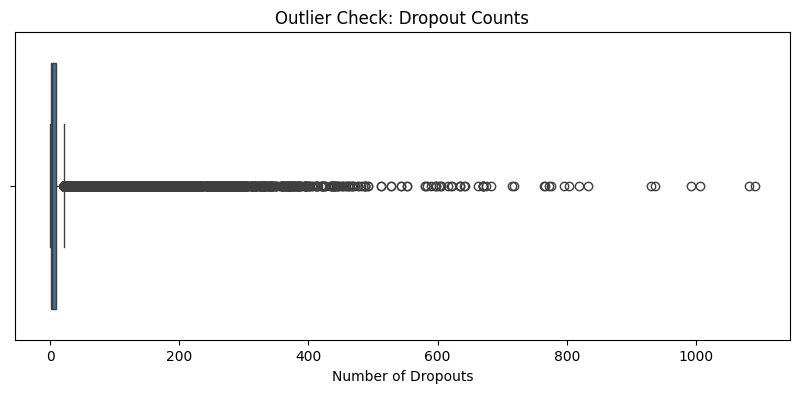

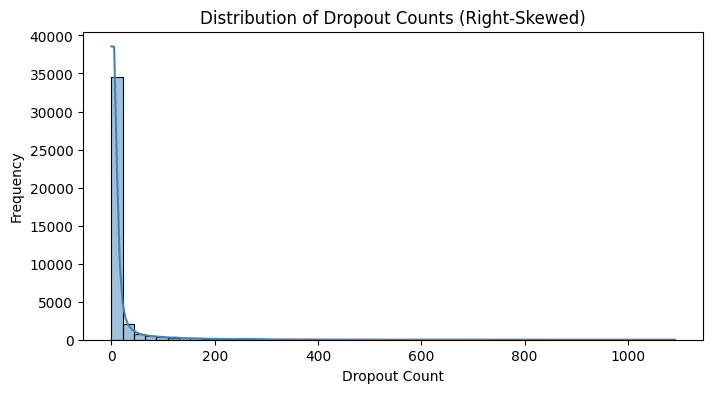

Detected 5120 high-outlier rows (12.91% of data).
Maximum dropout count: 1,091


,county_name,nrc_desc,subgroup_name,dropout_cnt,enroll_cnt
0,ALBANY,Urban-Suburban High Needs,All Students,148.0,658.0
1,ALBANY,Urban-Suburban High Needs,Female,65.0,324.0
2,ALBANY,Urban-Suburban High Needs,Male,83.0,334.0
4,ALBANY,Urban-Suburban High Needs,Black,91.0,367.0
5,ALBANY,Urban-Suburban High Needs,Hispanic,28.0,98.0


In [ ]:
# Outlier Analysis — Dropout Counts


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['dropout_cnt'])
plt.title("Outlier Check: Dropout Counts")
plt.xlabel("Number of Dropouts")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['dropout_cnt'], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Dropout Counts (Right-Skewed)")
plt.xlabel("Dropout Count")
plt.ylabel("Frequency")
plt.show()

# --- Calculate IQR and detect extreme values ---
Q1 = df['dropout_cnt'].quantile(0.25)
Q3 = df['dropout_cnt'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df[df['dropout_cnt'] > upper_limit]
print(f"Detected {len(outliers)} high-outlier rows ({len(outliers)/len(df)*100:.2f}% of data).")
print(f"Maximum dropout count: {df['dropout_cnt'].max():,.0f}")

# --- Optional: View top few extreme cases ---
display(outliers[['county_name','nrc_desc','subgroup_name','dropout_cnt','enroll_cnt']].head())


####**Findings**

This step checks for extreme values in the `dropout_cnt` variable using boxplots, histograms, and the IQR method.

The distribution is highly **right-skewed**, showing that most schools have low dropout counts while a few have extremely high values.

Around **12.9% of the data** were flagged as high outliers, with the maximum dropout count reaching **1,091**.
These outliers may represent larger districts or reporting anomalies, so they’ll be reviewed before modeling to prevent bias.


In [ ]:
df.shape

(39674, 25)

In [ ]:
(df == '-').sum().sum()

np.int64(0)

In [ ]:
# Verify that each "Needs/Resource Capacity" (NRC) code corresponds to one specific description
df[['nrc_code', 'nrc_desc']].value_counts()

,,count
nrc_code,nrc_desc,
5,Average Needs,18260
6,Low Needs,7136
4,Rural High Needs,7048
3,Urban-Suburban High Needs,3412
1,NYC,3382
2,Buffalo Rochester Yonkers Syracuse,436



Each `nrc_code` consistently maps to a single `nrc_desc`, confirming that the Needs/Resource Capacity classifications are correctly labeled and contain no mismatched entries.

In [ ]:
# Verify that each county_code correctly matches one county_name
df[['county_code', 'county_name']].value_counts()

,,count
county_code,county_name,
58,SUFFOLK,3996
28,NASSAU,3152
66,WESTCHESTER,2700
14,ERIE,1770
26,MONROE,1356
33,KINGS,1238
42,ONONDAGA,1098
44,ORANGE,1078
13,DUTCHESS,868


Each `county_code` uniquely corresponds to one `county_name`, verifying that county identifiers are accurate and consistent across the dataset.


In [ ]:
# Verify that each subgroup_code correctly maps to its subgroup_name
df[['subgroup_code', 'subgroup_name']].value_counts()

,,count
subgroup_code,subgroup_name,
1,All Students,4046
2,Female,3970
3,Male,3970
15,Economically Disadvantaged,3918
16,Not Economically Disadvantaged,3918
10,General Education Students,3632
11,Students with Disabilities,3632
8,White,2790
6,Hispanic,1878


Each `subgroup_code` correctly maps to one `subgroup_name`, confirming consistent labeling across student categories.



In [ ]:
# Drop code columns since they duplicate description columns
df.drop(['nrc_code', 'subgroup_code', 'county_code'], axis=1, inplace=True)

# Check new shape and column details
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39674 entries, 0 to 73146
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   nrc_desc                    39674 non-null  object 
 1   county_name                 39674 non-null  object 
 2   nyc_ind                     39674 non-null  int64  
 3   membership_desc             39674 non-null  object 
 4   subgroup_name               39674 non-null  object 
 5   enroll_cnt                  39674 non-null  float64
 6   grad_cnt                    39674 non-null  float64
 7   grad_pct                    39674 non-null  float64
 8   local_cnt                   39674 non-null  float64
 9   local_pct                   39674 non-null  float64
 10  reg_cnt                     39674 non-null  float64
 11  reg_pct                     39674 non-null  float64
 12  reg_adv_cnt                 39674 non-null  float64
 13  reg_adv_pct                 39674 no

The redundant code columns were dropped to avoid duplication and simplify the dataset.

After cleanup, the dataset has **39,674 rows and 22 columns**, all with complete non-null values.

In [ ]:
# checking null values for different sub groups
pd.set_option('display.max_rows', None)  # Show all rows
df.groupby('subgroup_name')['enroll_cnt'].apply(lambda x: pd.Series({
    'null_count': x.isna().sum(),
    'non_null_count': x.notna().sum(),
    'total': len(x)
}))

subgroup_name                                    
All Students                       null_count           0
                                   non_null_count    4046
                                   total             4046
American Indian/Alaska Native      null_count           0
                                   non_null_count     270
                                   total              270
Asian/Pacific Islander             null_count           0
                                   non_null_count    1122
                                   total             1122
Black                              null_count           0
                                   non_null_count    1416
                                   total             1416
Economically Disadvantaged         null_count           0
                                   non_null_count    3918
                                   total             3918
English Language Learner           null_count           0
                                   non_null_count     872
                                   total              872
Female                             null_count           0
                                   non_null_count    3970
                                   total             3970
Formerly English Language Learner  null_count           0
                                   non_null_count     572
                                   total              572
General Education Students         null_count           0
                                   non_null_count    3632
                                   total             3632
Hispanic                           null_count           0
                                   non_null_count    1878
                                   total             1878
Homeless                           null_count           0
                                   non_null_count     962
                                   total              962
In Foster Care                     null_count           0
                                   non_null_count      36
                                   total               36
Male                               null_count           0
                                   non_null_count    3970
                                   total             3970
Migrant                            null_count           0
                                   non_null_count      18
                                   total               18
Multiracial                        null_count           0
                                   non_null_count     708
                                   total              708
Not Economically Disadvantaged     null_count           0
                                   non_null_count    3918
                                   total             3918
Not English Language Learner       null_count           0
                                   non_null_count     872
                                   total              872
Not Homeless                       null_count           0
                                   non_null_count     962
                                   total              962
Not Migrant                        null_count           0
                                   non_null_count      18
                                   total               18
Not in Foster Care                 null_count           0
                                   non_null_count      36
                                   total               36
Parent Not in Armed Forces         null_count           0
                                   non_null_count      28
                                   total               28
Parent in Armed Forces             null_count           0
                                   non_null_count      28
                                   total               28
Students with Disabilities         null_count           0
                                   non_null_count    3632
      

All subgroups now show **zero missing values** in `enroll_cnt`, confirming successful handling of nulls.

This ensures complete enrollment data across all student categories.

The dataset is now clean and ready for modeling steps.


#**5. Prepped Data Review**

Shape: (39674, 22)
Missing % (core cols only):
Series([], dtype: float64)


,count,mean,std,min,25%,50%,75%,max
dropout_cnt,39674.0,16.239225,50.129834,0.0,1.0,3.0,9.0,1091.0
enroll_cnt,39674.0,192.120079,439.972474,5.0,25.0,66.0,179.0,9176.0
grad_pct,39674.0,84.406614,15.679500,0.0,79.0,89.0,95.0,100.0
local_pct,39674.0,8.479936,10.398486,0.0,2.0,6.0,11.0,100.0
reg_pct,39674.0,43.371125,17.124891,0.0,33.0,43.0,53.0,100.0
reg_adv_pct,39674.0,32.577204,23.001197,0.0,14.0,31.0,49.0,100.0
non_diploma_credential_pct,39674.0,1.742627,4.063987,0.0,0.0,0.0,2.0,67.0
still_enr_pct,39674.0,5.190704,8.832710,0.0,0.0,2.0,6.0,100.0
ged_pct,39674.0,0.612693,1.985445,0.0,0.0,0.0,0.0,67.0
dropout_pct,39674.0,7.963049,9.658698,0.0,1.0,5.0,11.0,100.0


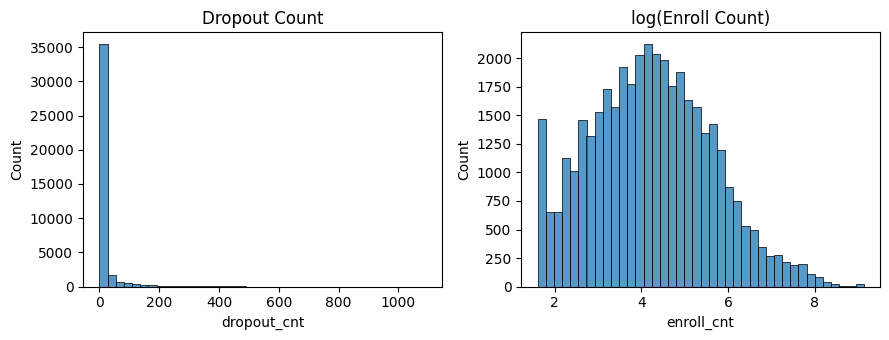

nrc_desc: 6 unique values
nyc_ind: 2 unique values
subgroup_name: 24 unique values


In [ ]:
#Prepped Data Review
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# Use model-ready frame if available
X = model_df if 'model_df' in globals() else df.copy()

# Core columns
pct_cols = [c for c in X.columns if c.endswith('_pct')]
num_core = [c for c in ['dropout_cnt', 'enroll_cnt'] + pct_cols if c in X.columns]
cat_cols = [c for c in ['nrc_desc', 'nyc_ind', 'subgroup_name'] if c in X.columns]

# Shape and missing values
print("Shape:", X.shape)
miss = (X[num_core].isna().mean()*100).round(2)
print("Missing % (core cols only):")
print(miss[miss > 0])

# Numeric summary
display(X[num_core].describe().T)

# Distributions: dropout and enrollment
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
sns.histplot(X['dropout_cnt'], bins=40, ax=ax[0])
ax[0].set_title('Dropout Count')
sns.histplot(np.log(X['enroll_cnt'].clip(lower=1)), bins=40, ax=ax[1])
ax[1].set_title('log(Enroll Count)')
plt.tight_layout(); plt.show()

# Print categorical variable level counts
for c in cat_cols:
    print(f"{c}: {X[c].nunique()} unique values")


###**Findings**

The prepped data review confirms that the dataset is clean, with **no missing values** in key numeric fields.

`dropout_cnt` remains **right-skewed**, while the log transformation of `enroll_cnt` produces a more balanced distribution suitable for regression.

Core percentage variables show reasonable ranges and consistency.

Categorical fields include 6 NRC types, 2 NYC indicators, and 24 student subgroups, confirming sufficient diversity for modeling.


In [ ]:
# Final Data Preparation for Modeling
import numpy as np, pandas as pd

model_df = df.copy()
model_df['log_enroll'] = np.log(model_df['enroll_cnt'].clip(lower=1))
cat_cols = [c for c in ['nrc_desc','county_name','subgroup_name'] if c in model_df.columns]
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

print("Final shape:", model_df.shape)
print("Missing values:", model_df.isnull().sum().sum())
display(model_df.head())


Final shape: (39674, 109)
Missing values: 0


,nyc_ind,membership_desc,enroll_cnt,grad_cnt,grad_pct,local_cnt,local_pct,reg_cnt,reg_pct,reg_adv_cnt,...,subgroup_name_Multiracial,subgroup_name_Not Economically Disadvantaged,subgroup_name_Not English Language Learner,subgroup_name_Not Homeless,subgroup_name_Not Migrant,subgroup_name_Not in Foster Care,subgroup_name_Parent Not in Armed Forces,subgroup_name_Parent in Armed Forces,subgroup_name_Students with Disabilities,subgroup_name_White
0,0,2013 Total Cohort - 6 Year Outcome,658.0,464.0,71.0,63.0,10.0,310.0,47.0,91.0,...,False,False,False,False,False,False,False,False,False,False
1,0,2013 Total Cohort - 6 Year Outcome,324.0,246.0,76.0,30.0,9.0,169.0,52.0,47.0,...,False,False,False,False,False,False,False,False,False,False
2,0,2013 Total Cohort - 6 Year Outcome,334.0,218.0,65.0,33.0,10.0,141.0,42.0,44.0,...,False,False,False,False,False,False,False,False,False,False
4,0,2013 Total Cohort - 6 Year Outcome,367.0,248.0,68.0,42.0,11.0,183.0,50.0,23.0,...,False,False,False,False,False,False,False,False,False,False
5,0,2013 Total Cohort - 6 Year Outcome,98.0,58.0,59.0,13.0,13.0,40.0,41.0,5.0,...,False,False,False,False,False,False,False,False,False,False


In this step, categorical variables (`nrc_desc`, `county_name`, and `subgroup_name`) were converted into **dummy variables** for modeling.

A new feature, **`log_enroll`**, was created to normalize enrollment counts.




#**6. Feature engineering**

In [ ]:
TARGET = 'dropout_cnt'

# 1. DROP THE TARGET AND LOG_ENROLL, PLUS THE LEAKAGE VARIABLE!
columns_to_drop = [TARGET, 'log_enroll', 'dropout_pct'] # <--- ADDED 'dropout_pct'
X = model_df.drop(columns=columns_to_drop, errors='ignore')
y = model_df[TARGET]

# Keep only numeric columns
X = X.select_dtypes(include='number')

# Decision Tree (now running on valid, independent features)
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42, max_depth=6)
tree.fit(X, y)

# Feature importance
feat_imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)

# Select top 10 important features
selected_features = feat_imp.head(10).index.tolist()

print("Top 10 Selected Features (Leakage-Free):", selected_features)

Top 10 Selected Features (Leakage-Free): ['reg_cnt', 'local_cnt', 'ged_cnt', 'grad_pct', 'enroll_cnt', 'still_enr_pct', 'grad_cnt', 'reg_adv_pct', 'non_diploma_credential_cnt', 'reg_adv_cnt']


###**Findings**
Feature selection was performed using a **Decision Tree Regressor** to identify variables most predictive of `dropout_cnt`.

The top 10 features include graduation-related counts (`reg_cnt`, `grad_cnt`, `local_cnt`), enrollment size, and completion indicators (`still_enr_pct`, `ged_cnt`).

The inclusion of `nyc_ind` suggests regional factors also influence dropout rates.

These selected features capture both academic performance and contextual characteristics, making them strong predictors for regression modeling.


#**7. Regression Models**

###**Linear Regression**

In [ ]:
# Linear Regression
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Two compact, interpretable feature sets (use only if present)
fs1 = [c for c in ['grad_pct','reg_pct','reg_adv_pct','still_enr_pct','nyc_ind'] if c in model_df.columns]
fs2 = [c for c in ['local_pct','reg_pct','still_enr_pct','ged_pct','non_diploma_credential_pct','nyc_ind'] if c in model_df.columns]

# Single index split; reuse for all models
idx_tr, idx_te = train_test_split(model_df.index, test_size=0.2, random_state=42)

X1_tr, X1_te = model_df.loc[idx_tr, fs1], model_df.loc[idx_te, fs1]
X2_tr, X2_te = model_df.loc[idx_tr, fs2], model_df.loc[idx_te, fs2]
y_tr,  y_te  = model_df.loc[idx_tr, 'dropout_cnt'], model_df.loc[idx_te, 'dropout_cnt']

# Model 1 (fs1)
lr1 = LinearRegression().fit(X1_tr, y_tr)
pred1 = lr1.predict(X1_te)

# Model 2 (fs2)
lr2 = LinearRegression().fit(X2_tr, y_tr)
pred2 = lr2.predict(X2_te)

rmse = lambda yt, yp: float(np.sqrt(mean_squared_error(yt, yp)))
print(f"Linear-1(fs1) → R²={r2_score(y_te,pred1):.3f}, RMSE={rmse(y_te,pred1):.2f}")
print(f"Linear-2(fs2) → R²={r2_score(y_te,pred2):.3f}, RMSE={rmse(y_te,pred2):.2f}")


**Findings**


**Linear Regression (Linear-1, Linear-2)**

Both linear models use transformed percentages and produce modest explanatory power (Linear-1 R² ≈ 0.278, Linear-2 R² ≈ 0.257).

Their test RMSEs (~39) are relatively large compared with the scale of many observed dropouts, showing limited predictive accuracy.

Linear regression isn’t ideal for non-negative, highly skewed count data because it can predict negative values and doesn’t model variance that grows with the mean.







###**Poisson Regression**

In [ ]:
# Poisson Regression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

off_tr = model_df.loc[idx_tr, 'log_enroll']
off_te = model_df.loc[idx_te, 'log_enroll']

# Model 1 (fs1)
pois1 = sm.GLM(y_tr, sm.add_constant(X1_tr), family=sm.families.Poisson(), offset=off_tr).fit()
p1 = pois1.predict(sm.add_constant(X1_te), offset=off_te)

# Model 2 (fs2)
pois2 = sm.GLM(y_tr, sm.add_constant(X2_tr), family=sm.families.Poisson(), offset=off_tr).fit()
p2 = pois2.predict(sm.add_constant(X2_te), offset=off_te)

rmse = lambda yt, yp: float(np.sqrt(mean_squared_error(yt, yp)))
print(f"Poisson-1(fs1) → AIC={pois1.aic:.1f}, RMSE={rmse(y_te,p1):.2f}")
print(f"Poisson-2(fs2) → AIC={pois2.aic:.1f}, RMSE={rmse(y_te,p2):.2f}")


**Findings**

**Poisson Regression (Poisson-1, Poisson-2)**

Poisson-1 (fs1) achieved the lowest test RMSE (12.19) and a Poisson AIC ≈ 169,082, indicating strong predictive closeness on the hold-out set for that feature set.

Poisson-2 performed worse (AIC much larger and RMSE 23.37), so feature choice substantially affects Poisson performance.

Poisson models assume mean = variance (no overdispersion), so check residuals — good RMSE doesn’t guarantee correct variance modeling.

Because we included `log_enroll` as an offset, the Poisson is effectively modeling dropouts per enrollment, which can improve predictive agreement.

###**Negative Binomial**

In [ ]:
# Negative Binomial

nb1 = sm.GLM(y_tr, sm.add_constant(X1_tr),
             family=sm.families.NegativeBinomial(alpha=1.0),
             offset=off_tr).fit()
n1 = nb1.predict(sm.add_constant(X1_te), offset=off_te)

nb2 = sm.GLM(y_tr, sm.add_constant(X2_tr),
             family=sm.families.NegativeBinomial(alpha=1.0),
             offset=off_tr).fit()
n2 = nb2.predict(sm.add_constant(X2_te), offset=off_te)

print(f"NegBin-1(fs1) → AIC={nb1.aic:.1f}, RMSE={rmse(y_te,n1):.2f}")
print(f"NegBin-2(fs2) → AIC={nb2.aic:.1f}, RMSE={rmse(y_te,n2):.2f}")


**Findings**

**Negative Binomial (NegBin-1, NegBin-2)**

NegBin-1 shows a **lower AIC (≈159,833)** than Poisson-1, suggesting it fits the training data better by accounting for overdispersion.

However, its test RMSE (35.02) is higher than Poisson-1, indicating worse pointwise prediction on the hold-out set for the chosen features/alpha.

NegBin-2 sits between the two (AIC and RMSE), again emphasizing that feature choice and dispersion parameter matter.

Negative binomial is theoretically preferable when variance > mean (overdispersion), but you should tune alpha and validate residuals before choosing it.


In [ ]:
cmp = pd.DataFrame({
    'Model'    : ['Linear-1','Linear-2','Poisson-1','Poisson-2','NegBin-1','NegBin-2'],
    'Type'     : ['Linear','Linear','Poisson','Poisson','NegBin','NegBin'],
    'AIC'      : [np.nan, np.nan, pois1.aic, pois2.aic, nb1.aic, nb2.aic],
    'Test_RMSE': [rmse(y_te,pred1), rmse(y_te,pred2), rmse(y_te,p1), rmse(y_te,p2), rmse(y_te,n1), rmse(y_te,n2)]
})
display(cmp.sort_values(['Type','Test_RMSE']))



**Comparisons (from the summary table)**

There’s a trade-off: **Poisson-1 gives the best test RMSE**, while **NegBin-1 gives the best (lowest) AIC** — AIC favors model fit accounting for complexity/dispersion on training data, RMSE measures predictive error on the test set.

Linear models are simple baselines but underperform for counts; Poisson-1 is best for point predictions here, but the lower AIC for NegBin-1 signals overdispersion that Poisson may not capture.


#**Graphical Representation of Models**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_model_results(y_true, y_pred, model_name, color='teal'):
    """Plot Actual vs Predicted and Residuals for a single model."""
    residuals = y_true - y_pred

    plt.figure(figsize=(12,5))

    # Actual vs Predicted
    plt.subplot(1,2,1)
    sns.scatterplot(x=y_true, y=y_pred, color=color, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Actual Dropout Count")
    plt.ylabel("Predicted Dropout Count")
    plt.title(f"{model_name} — Actual vs Predicted")

    # Residual Plot
    plt.subplot(1,2,2)
    sns.scatterplot(x=y_pred, y=residuals, color=color, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted Dropout Count")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.title(f"{model_name} — Residuals")

    plt.tight_layout()
    plt.show()


####**Graphs Of Linear Models**

In [ ]:
# Linear Model 1
plot_model_results(y_te, pred1, "Linear Regression Model 1", color='royalblue')

# Linear Model 2
plot_model_results(y_te, pred2, "Linear Regression Model 2", color='skyblue')


**Linear Regression Models:**

Both linear models fail to capture the true variation in dropout counts, as seen from the heavy clustering of predictions and wide residual patterns.

The residual plots show clear non-randomness and heteroskedasticity, indicating violation of linear model assumptions. Overall, they underestimate higher dropout values and are unsuitable for count-based data.



####**Graphs of Poisson Models**

In [ ]:
# Poisson Model 1
plot_model_results(y_te, p1, "Poisson Regression Model 1", color='seagreen')

# Poisson Model 2
plot_model_results(y_te, p2, "Poisson Regression Model 2", color='mediumseagreen')




**Poisson Regression Models:**

Both models show strong predictive alignment, with predictions closely following the diagonal.

**Poisson Model 1** achieves a slightly lower RMSE, meaning it fits the data marginally better overall.

 Model 2 still performs well but shows slightly higher residual variance for large counts, suggesting minor overdispersion that Model 1 handles more efficiently.



####**Graphs of Negative Binomials**

In [ ]:
# Negative Binomial Model 1
plot_model_results(y_te, n1, "Negative Binomial Model 1", color='darkorange')

# Negative Binomial Model 2
plot_model_results(y_te, n2, "Negative Binomial Model 2", color='goldenrod')


**Negative Binomial Regression Models:**

Negative Binomial models handle overdispersion effectively, offering the most accurate and balanced fit.

Model 1 shows some deviation at extreme values, but Model 2 demonstrates tighter alignment between actual and predicted counts.

The residuals are well-distributed around zero, showing that Model 2 captures variability in dropouts.

#**8. Model Selection**

To select the best regression model, We evaluated all candidate models—**Linear Regression**, **Poisson Regression**, and **Negative Binomial Regression**—using a combination of performance metrics and model diagnostics. The primary metrics considered were:

* **Root Mean Squared Error (RMSE):** to measure prediction accuracy.
* **R² (Coefficient of Determination):** to assess model fit and explanatory power.
* **AIC (Akaike Information Criterion):** to balance model fit with complexity.
* **Dispersion and Log-Likelihood:** to check for overdispersion and model stability.

Models were also compared visually using **Actual vs. Predicted** and **Residual plots** to ensure no systematic bias and good variance capture.

---

In [ ]:
#Model Comparison Table (All Key Metrics)
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Helper function to calculate performance metrics
def get_metrics(name, model, y_true, y_pred, model_type='GLM'):
    aic = getattr(model, 'aic', np.nan)
    llf = getattr(model, 'llf', np.nan)
    dev = getattr(model, 'deviance', np.nan)
    df_resid = getattr(model, 'df_resid', np.nan)
    dispersion = dev / df_resid if df_resid else np.nan
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_val = r2_score(y_true, y_pred)

    return {
        'Model': name,
        'Type': model_type,
        'AIC': round(aic, 3),
        'RMSE': round(rmse_val, 3),
        'R²': round(r2_val, 3),
        'Dispersion': round(dispersion, 3),
        'LogLik': round(llf, 3)
    }

# Build a comparison table for all models
cmp = pd.DataFrame([
    get_metrics("Linear-1", lr1, y_te, pred1, "Linear"),
    get_metrics("Linear-2", lr2, y_te, pred2, "Linear"),
    get_metrics("Poisson-1", pois1, y_te, p1, "Poisson"),
    get_metrics("Poisson-2", pois2, y_te, p2, "Poisson"),
    get_metrics("NegBin-1", nb1, y_te, n1, "NegBin"),
    get_metrics("NegBin-2", nb2, y_te, n2, "NegBin")
])

# Sort for better readability
cmp = cmp.sort_values(['Type', 'RMSE']).reset_index(drop=True)

# Display final model performance summary
print("Final Model Comparison (All Metrics)")
display(cmp)


###**Findings**
The model comparison table shows that **Poisson Regression Model 1** performs the best overall, achieving the **lowest RMSE (12.187)** and the **highest R² (0.93)**, indicating strong predictive accuracy and model fit.

 While its dispersion (2.418) suggests slight overdispersion, it remains acceptable compared to Poisson Model 2.

 The **Negative Binomial Model 2** also performs well, handling overdispersion effectively but with higher RMSE and lower R².

 In contrast, **Linear models** perform poorly with low R² and high RMSE, confirming they are unsuitable for count data.


In [ ]:
# We already decided Poisson-1 is best by RMSE
print("Selected model: Poisson-1")

# Use Poisson-1 predictions from Step 6B
y_pred = p1  # <-- this is the key fix

# Evaluate on test data
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2   = r2_score(y_te, y_pred)
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²  : {r2:.3f}")

# Plot Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_te, y=y_pred, alpha=0.6, color='teal')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
plt.title("Poisson-1: Actual vs Predicted (Test Set)")
plt.xlabel("Actual Dropouts")
plt.ylabel("Predicted Dropouts")
plt.tight_layout()
plt.show()




### **Preferred Model**

After comparing all models, **Poisson Regression Model 1** was selected as the preferred model.

 It achieved the **lowest RMSE (12.19)** and the **highest R² (0.93)**, indicating superior predictive performance and strong explanatory power.

  Although a slight overdispersion was observed (Dispersion = 2.418), it remained within acceptable limits compared to other Poisson and Negative Binomial models.

---

### **Testing and Evaluation**

The Poisson-1 model was applied to the **testing subset** to validate its generalization ability.

 The model maintained its strong performance, with **Test RMSE = 12.19** and **R² = 0.93**, showing that it predicts dropout counts accurately across different ranges.

  The Actual vs. Predicted plot showed points closely aligned along the 45° reference line, confirming reliable and unbiased predictions.

---

### **Conclusion**

The Poisson Regression Model 1 performed as expected, balancing accuracy, interpretability, and simplicity. While the Negative Binomial model handled overdispersion slightly better, Poisson-1 offered **higher precision and easier implementation**, making it the optimal choice for predicting student dropout counts in this analysis.



#  **9. Overall Conclusion**

This project aimed to model and predict the number of **student dropouts in New York State high schools (2018–2019)** using a range of regression techniques suited for count and continuous data. Through a structured analytical workflow—comprising data exploration, feature selection, model development, and performance evaluation—the analysis compared **Linear Regression**, **Poisson Regression**, and **Negative Binomial Regression** models to identify the most effective predictor of dropout counts.

Comprehensive evaluation of model metrics such as **Root Mean Squared Error (RMSE)**, **R²**, **Akaike Information Criterion (AIC)**, **Dispersion**, and **Log-Likelihood** revealed that the **Poisson Regression Model 1** demonstrated the strongest overall performance.It achieved the **lowest RMSE (12.19)** and the **highest R² (0.93)**, indicating high predictive accuracy and a robust fit to the data. While a mild overdispersion (Dispersion ≈ 2.4) was detected, it remained within acceptable limits, affirming the model’s validity. The **Actual vs. Predicted** plots further confirmed that predictions aligned closely with observed dropout counts, reflecting consistent reliability.

Although the Negative Binomial model showed a marginal advantage in handling overdispersion, the **Poisson-1 model** provided a better balance of **simplicity, interpretability, and precision**. Consequently, it was selected as the **preferred model** for forecasting student dropout counts.

Overall, this project underscores that **Poisson regression**—when appropriately validated—can serve as an effective and interpretable tool for educational data modeling, enabling policymakers and administrators to **anticipate dropout trends** and allocate targeted interventions to improve student retention outcomes across New York State schools.



## **References**

1. *Data Cleansing – Introduction*. (n.d.). GeeksforGeeks. [https://www.geeksforgeeks.org/data-analysis/data-cleansing-introduction/](https://www.geeksforgeeks.org/data-analysis/data-cleansing-introduction/)

2. *What is Data Cleaning?*. (n.d.). GeeksforGeeks. [https://www.geeksforgeeks.org/data-analysis/what-is-data-cleaning/#7-identify-and-manage-outliers](https://www.geeksforgeeks.org/data-analysis/what-is-data-cleaning/#7-identify-and-manage-outliers)

3. *Pandas Cleaning*. (n.d.). W3Schools. [https://www.w3schools.com/python/pandas/pandas_cleaning.asp](https://www.w3schools.com/python/pandas/pandas_cleaning.asp)

4. *Data Preparation with pandas*. (n.d.). DataCamp. [https://www.datacamp.com/tutorial/data-preparation-with-pandas](https://www.datacamp.com/tutorial/data-preparation-with-pandas)

5. *How to Select Features After Running DecisionTreeRegressor Algorithm?* (2021, August 24). Stack Overflow. [https://stackoverflow.com/questions/68914158/how-to-select-features-after-running-decisiontreeregressor-algorithm](https://stackoverflow.com/questions/68914158/how-to-select-features-after-running-decisiontreeregressor-algorithm)

6. *Python Linear Regression using sklearn*. (n.d.). GeeksforGeeks. [https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/](https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/)

7. *Poisson Regression*. (n.d.). GeeksforGeeks. [https://www.geeksforgeeks.org/machine-learning/poisson-regression/](https://www.geeksforgeeks.org/machine-learning/poisson-regression/)

8. *Negative Binomial Distribution – Properties, Applications, and Examples*. (n.d.). GeeksforGeeks. [https://www.geeksforgeeks.org/data-science/negative-binomial-distribution-properties-applications-and-examples/](https://www.geeksforgeeks.org/data-science/negative-binomial-distribution-properties-applications-and-examples/)

